## 1. Dataset


Source: ```https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis```

1. Delivery Status
2. Late Delivery Risks
3. Type (of payment?)
4. Order Status (Fraud!)
5. Sales, Profit, etc

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload
import plotly.express as px

import seaborn as sns
from sklearn import tree
from sklearn.feature_selection import mutual_info_classif
from collections import defaultdict

from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
import inspect


sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot
import CIBayes

### 1.1 Objective

In [2]:
descr = pd.read_csv('../Raw/DescriptionDataCoSupplyChain.csv').set_index('FIELDS')
descr['DESCRIPTION'].str.replace(':  ', '').to_dict()

{'Type': 'Type of transaction made',
 'Days for shipping (real)     ': 'Actual shipping days of the purchased product',
 'Days for shipment (scheduled)': 'Days of scheduled delivery of the purchased product',
 'Benefit per order': 'Earnings per order placed',
 'Sales per customer': 'Total sales per customer made per customer',
 'Delivery Status': 'Delivery status of orders: Advance shipping , Late delivery , Shipping canceled , Shipping on time',
 'Late_delivery_risk           ': 'Categorical variable that indicates if sending is late (1), it is not late (0).',
 'Category Id': 'Product category code',
 'Category Name': 'Description of the product category',
 'Customer City': 'City where the customer made the purchase',
 'Customer Country': 'Country where the customer made the purchase',
 'Customer Email': "Customer's email",
 'Customer Fname': 'Customer name',
 'Customer Id': 'Customer ID',
 'Customer Lname': 'Customer lastname',
 'Customer Password': 'Masked customer key',
 'Customer 

### 1.2. Data Cleaning

In [3]:
df = pd.read_csv('../Raw/DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
df = df.set_index('Order Item Id')
df = df.drop(columns=['Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 
                     'Product Image', 'Product Description'])

date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
df[date_cols] = df[date_cols].apply(lambda s: pd.to_datetime(s, format='%m/%d/%Y %H:%M'))
df['Customer Zipcode'] = df['Customer Zipcode'].astype(str)
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
Order Item Id,,,,,,,,,,,,,,,,,,,,,
180517,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class
179254,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,NaN,1360,73,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class
179253,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class
179252,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class
179251,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65177,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Shanghái,CLOSED,NaN,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
65161,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Osaka,COMPLETE,NaN,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
65129,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Australia del Sur,PENDING,NaN,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class


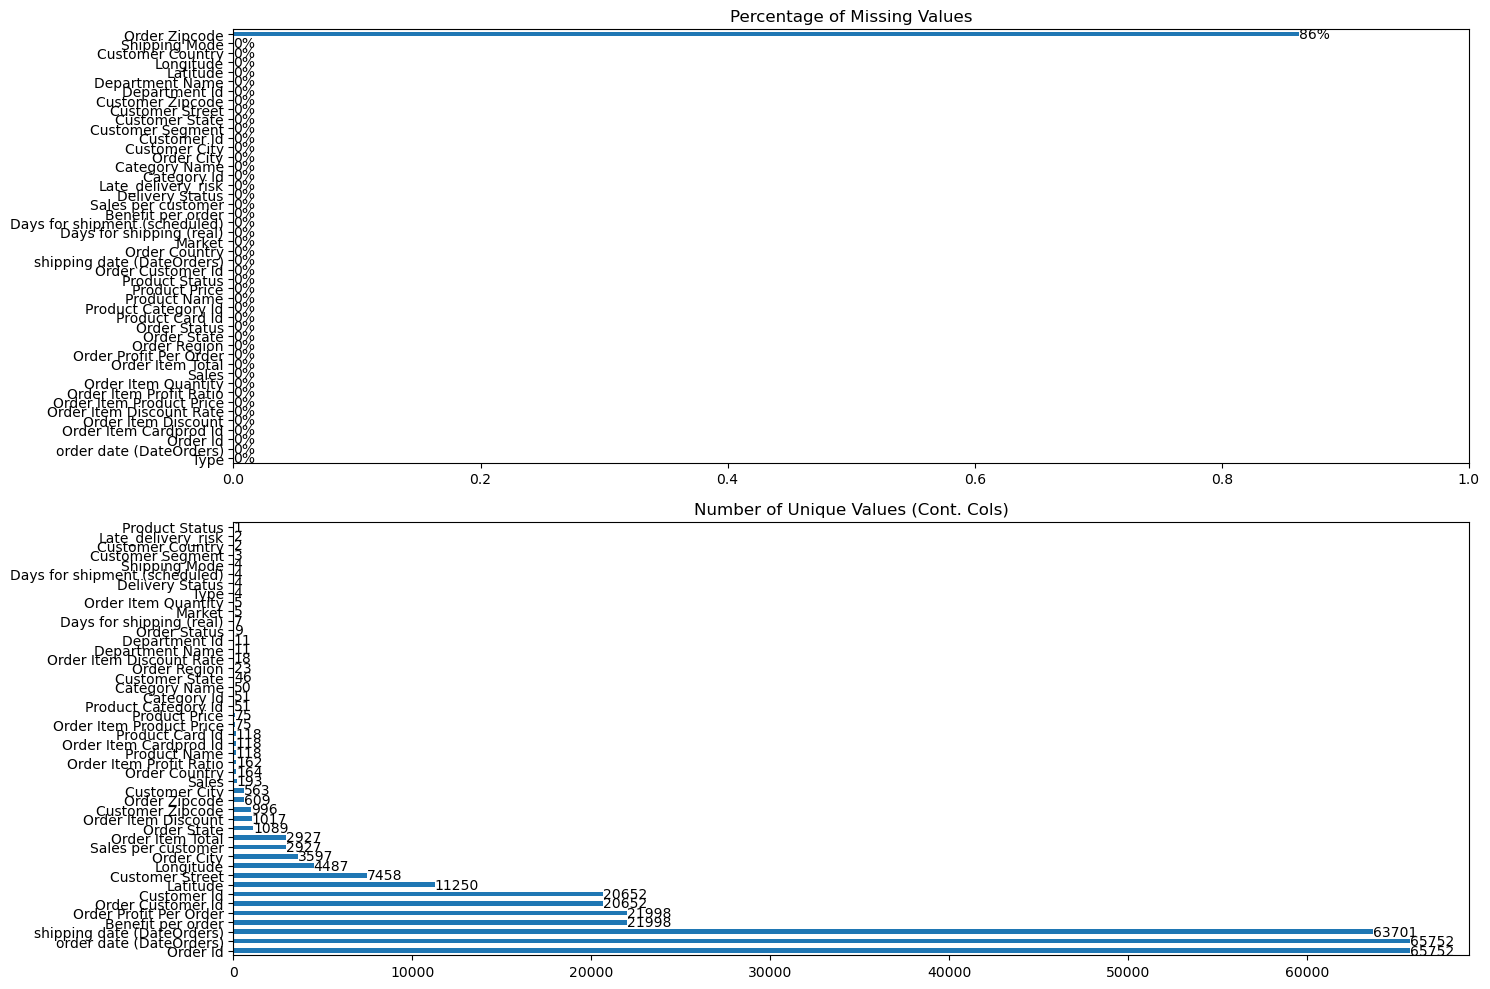

In [4]:
pplot.data_quality_check(df)
df = df.drop(columns=['Order Zipcode', # 86% Missing 
                      'Product Status']) # Only 1 Unique

In [5]:
uniq_mapping = {}

for c in df.columns:
    nuniq = df.groupby(c).nunique()
    is_mapped_to_unique = nuniq.columns[nuniq.max() == 1] # check 1 to n
    
    mapping2 = [c2 for c2 in is_mapped_to_unique if df.groupby(c2)[c].nunique().max() == 1]
    if len(mapping2) > 0:
        for c2 in mapping2:
            if c2 in uniq_mapping:
                if c in uniq_mapping[c2]:
                    continue
                    
            if c not in uniq_mapping:
                uniq_mapping[c] = []
            uniq_mapping[c].append(c2)

uniq_mapping

{'Days for shipment (scheduled)': ['Shipping Mode'],
 'Benefit per order': ['Order Profit Per Order'],
 'Sales per customer': ['Order Item Total'],
 'Category Id': ['Product Category Id'],
 'Customer Id': ['Order Customer Id'],
 'Department Id': ['Department Name'],
 'order date (DateOrders)': ['Order Id'],
 'Order Item Cardprod Id': ['Product Card Id', 'Product Name'],
 'Order Item Product Price': ['Product Price'],
 'Product Card Id': ['Product Name']}

In [6]:
df = df.drop(columns=['Order Id', #'order date (DateOrders)'
                      'Product Card Id', 'Order Item Cardprod Id', #'Product Name'
                     'Product Category Id', #'Category Id'
                     'Order Customer Id', #'Customer Id'
                     'Department Id', #'Department Name'
                      'Category Id', #'Category Name'
                      'Customer Id', # Too Sparse
                     ])

In [7]:
df.sample(5).T#.iloc[:, 17:24].sample(5).values

Order Item Id,65689,17544,73433,166383,5694
Type,TRANSFER,DEBIT,PAYMENT,DEBIT,DEBIT
Days for shipping (real),3,3,3,2,6
Days for shipment (scheduled),4,2,4,1,2
Benefit per order,73.800003,6.14,55.43,45.919998,64.099998
Sales per customer,163.990005,49.130001,158.369995,170.070007,237.410004
Delivery Status,Shipping canceled,Late delivery,Advance shipping,Late delivery,Late delivery
Late_delivery_risk,0,1,0,1,1
Category Name,Water Sports,Electronics,Cleats,Cleats,Indoor/Outdoor Games
Customer City,Jacksonville,New Castle,Wyoming,Apex,Hickory
Customer Country,EE. UU.,EE. UU.,EE. UU.,EE. UU.,EE. UU.


## 2. EDA Wrapper

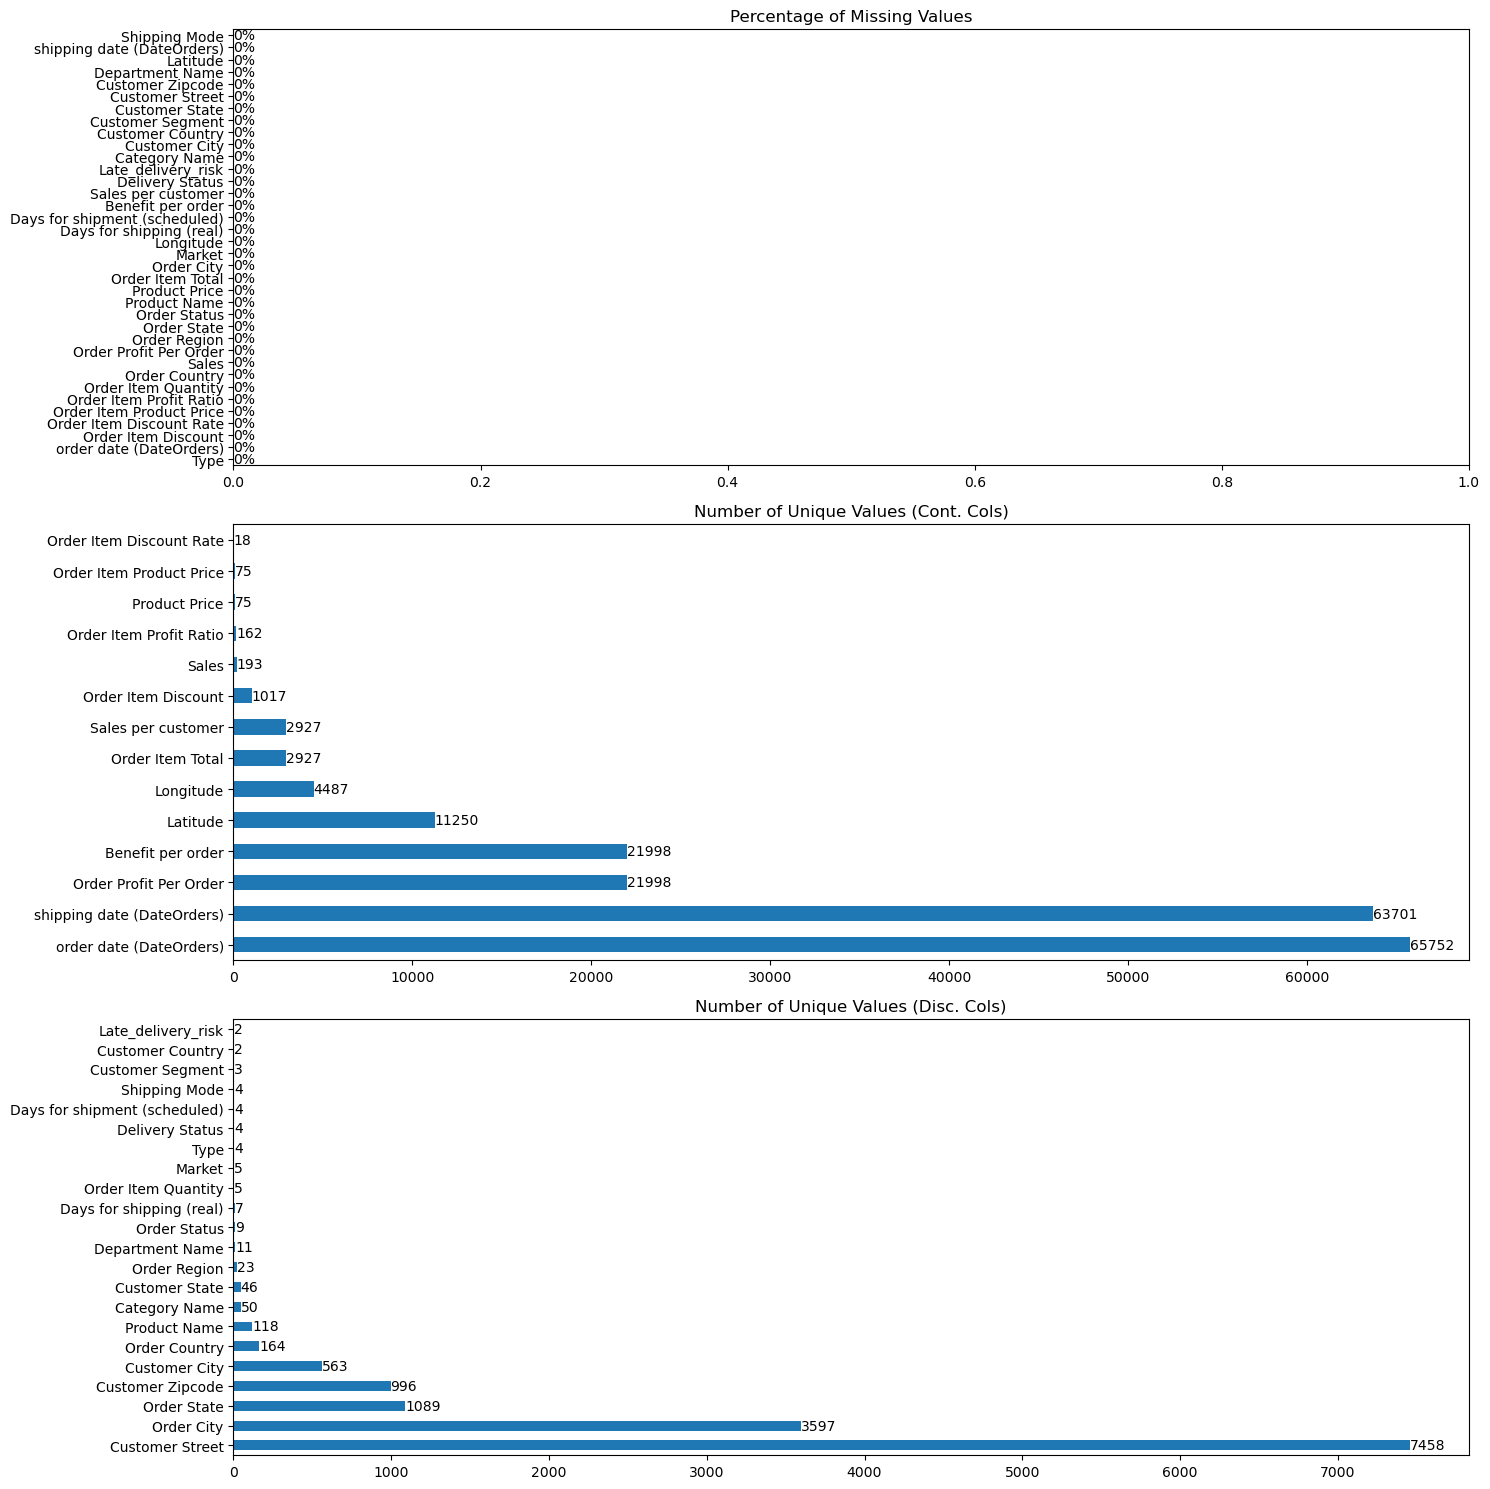

In [8]:
target = 'Late_delivery_risk'
cont_thres = 'log2'
random_state = 4012
verbose = False

dta = pan.DataAnalyzer(df, target=target, verbose=verbose,
                      cont_thres=cont_thres, random_state=random_state)

dta.data_quality_check(one_figsize=(15, 5), check_zero=False);

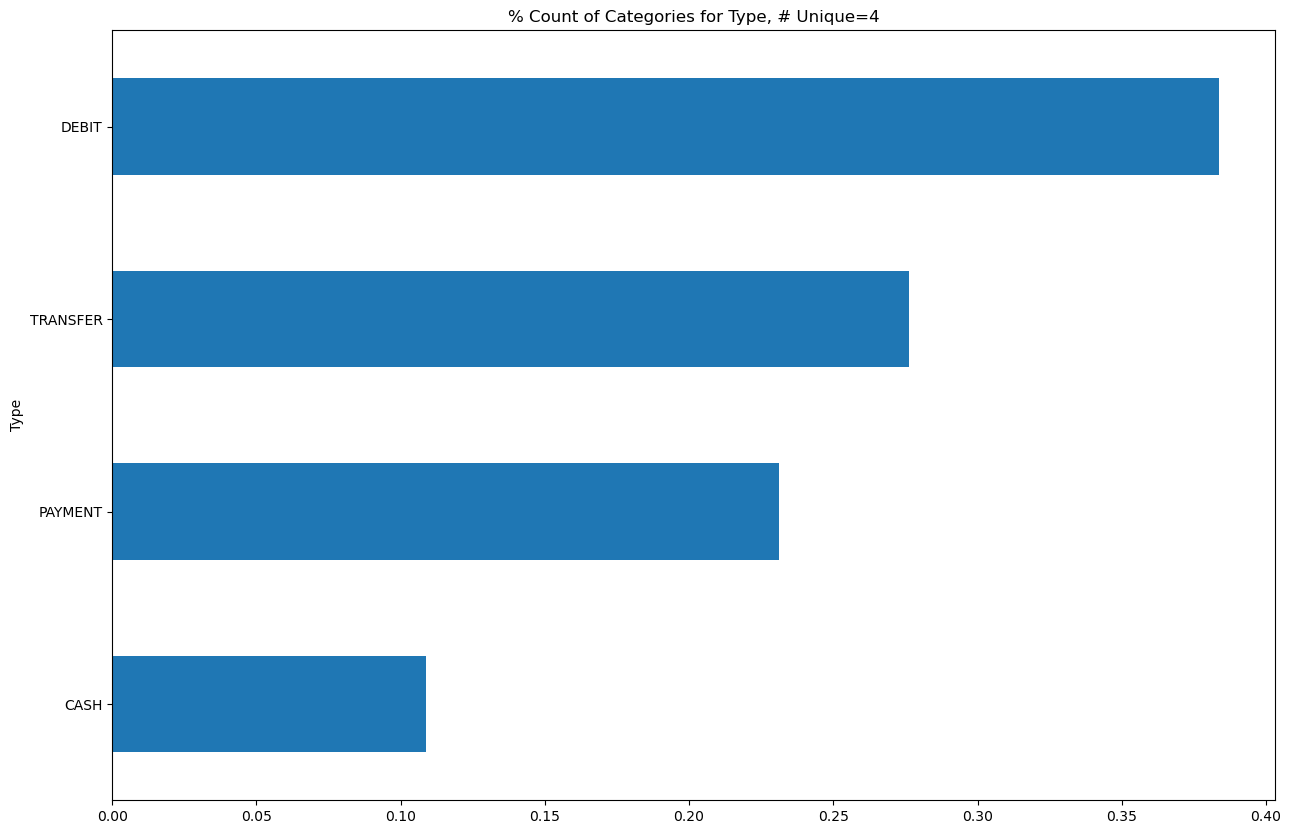

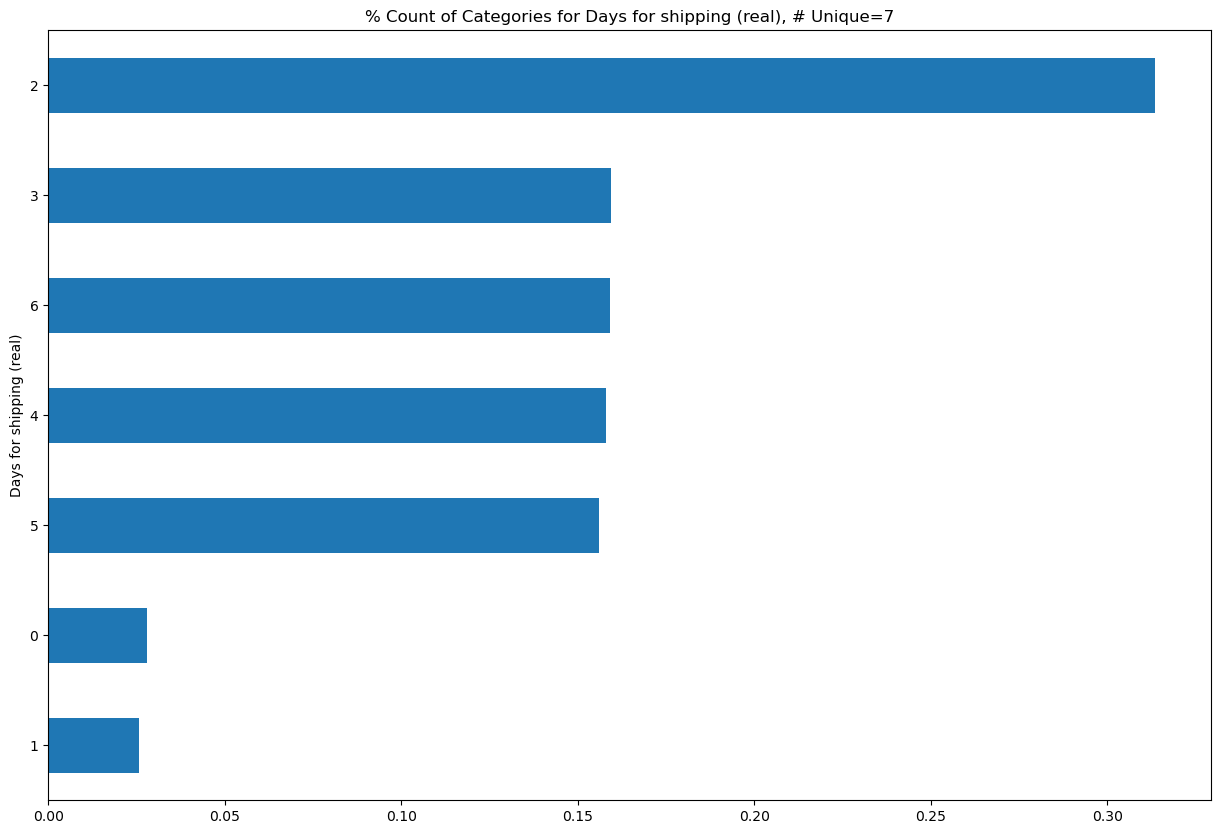

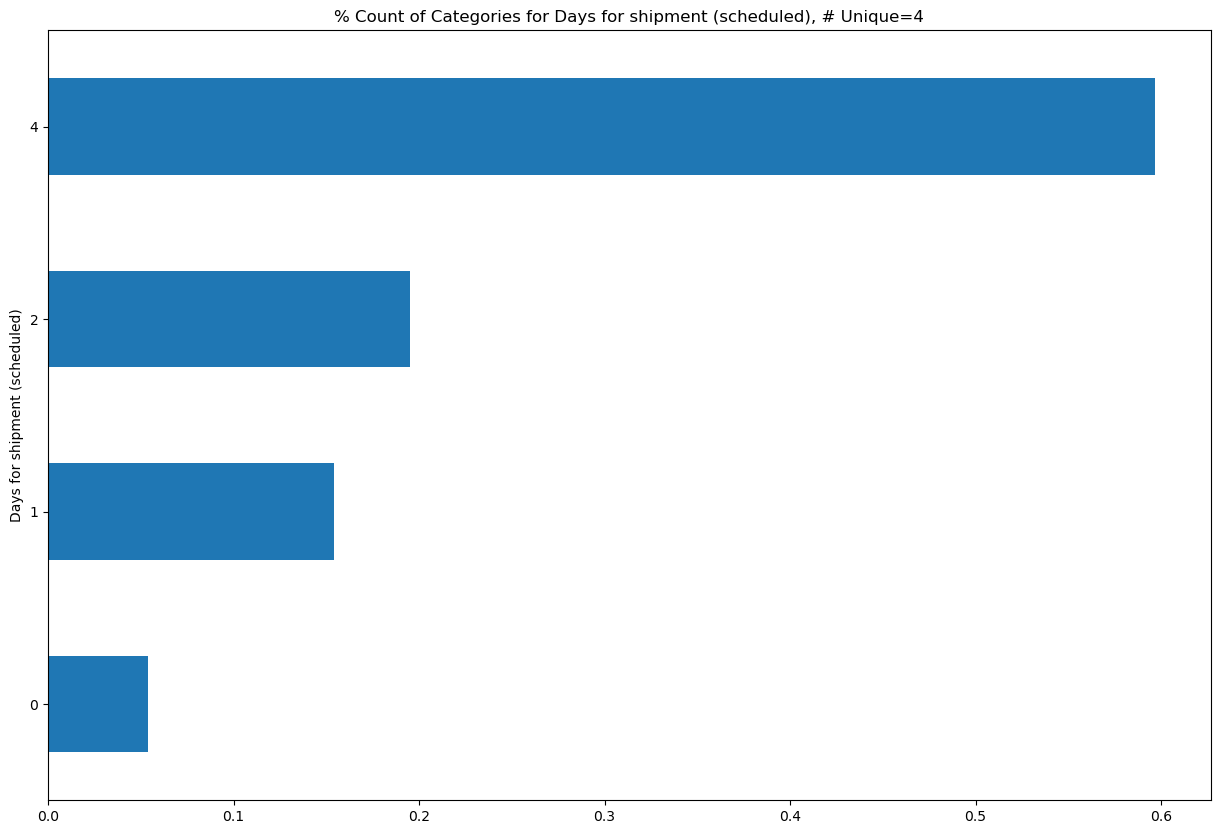

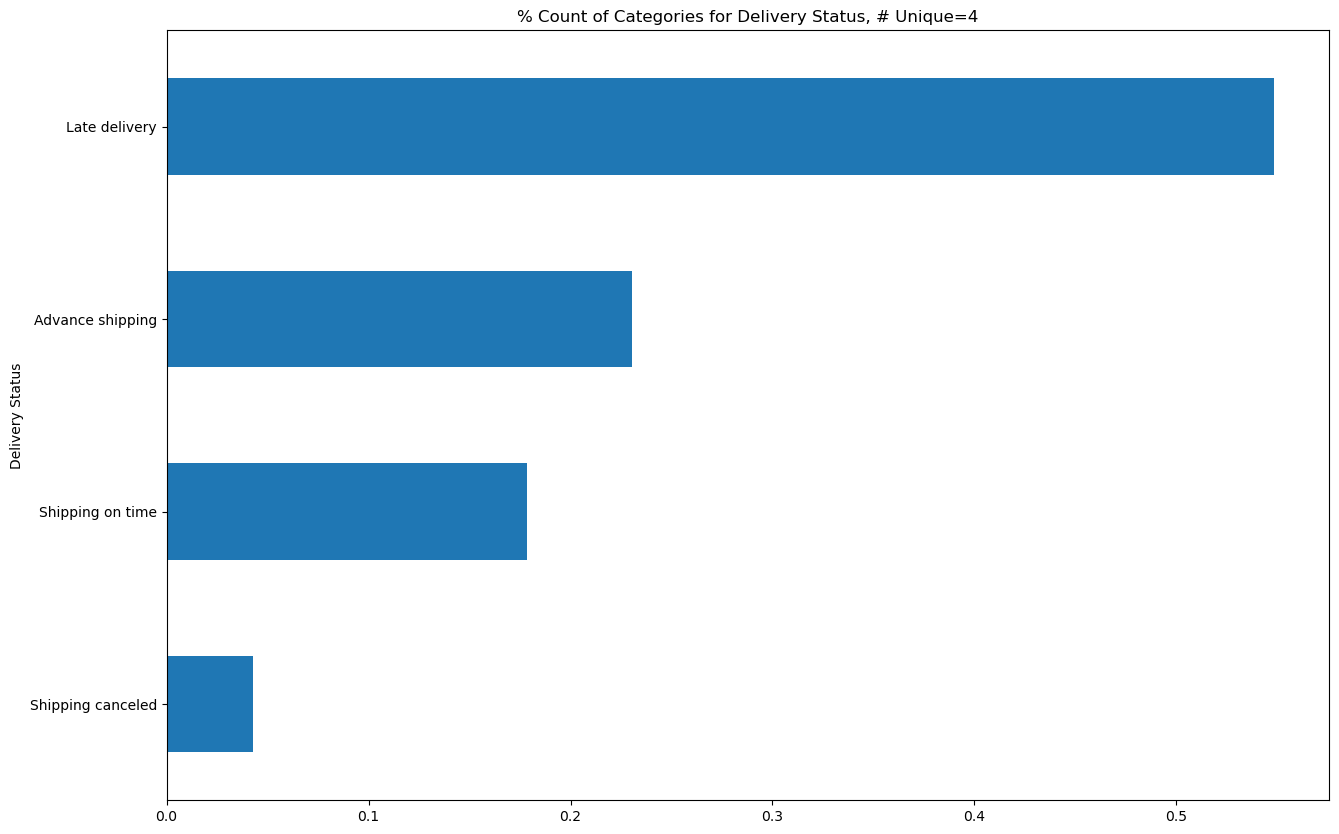

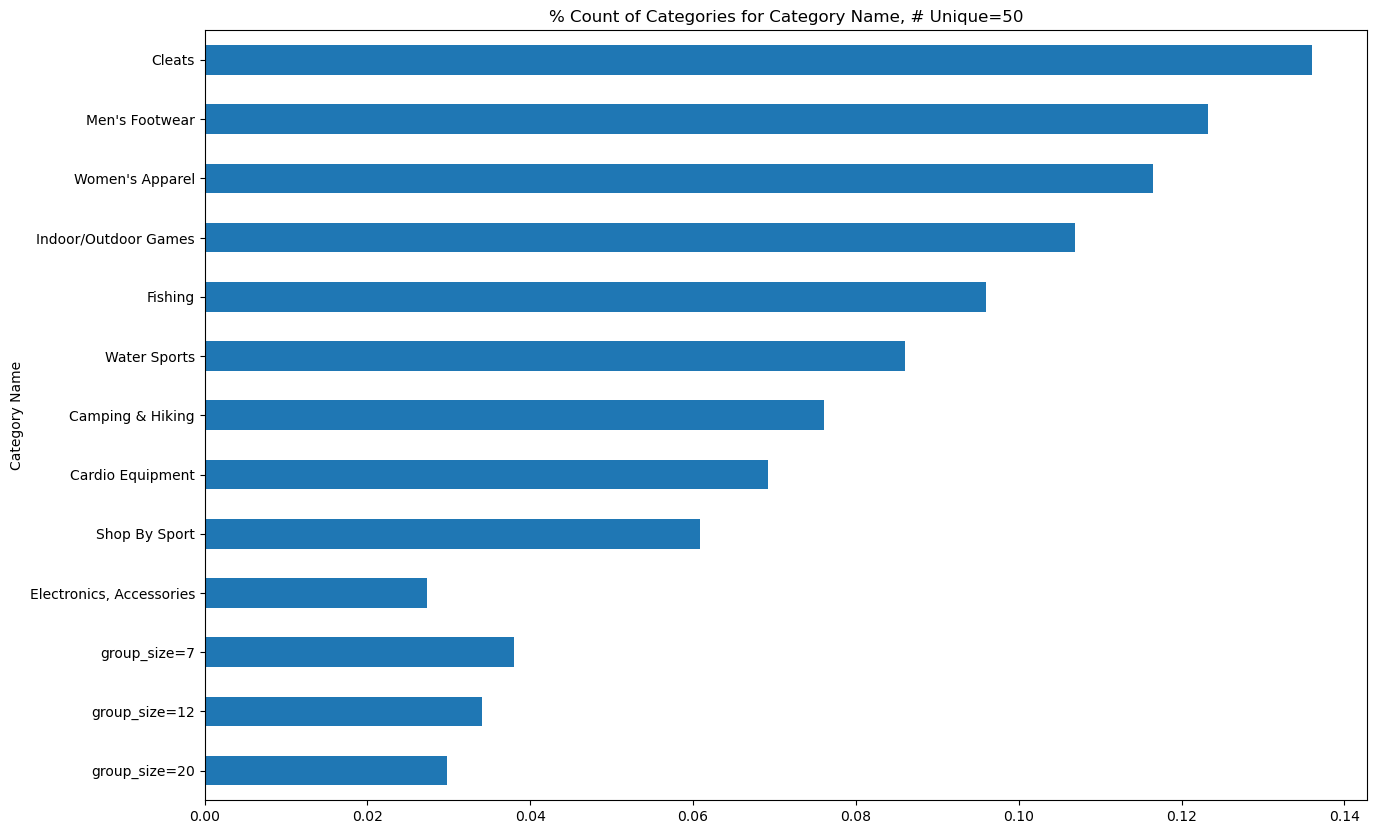

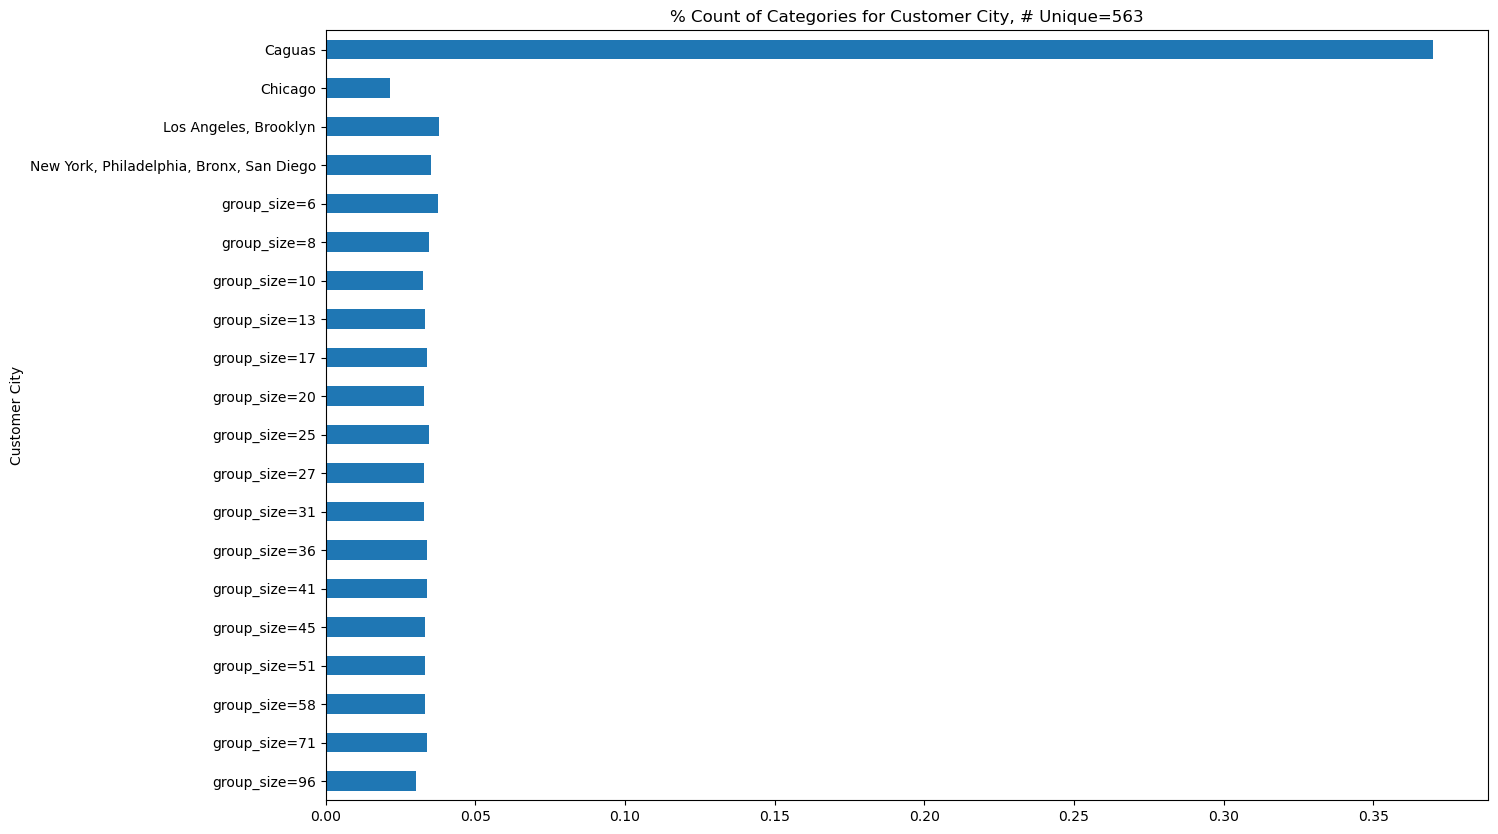

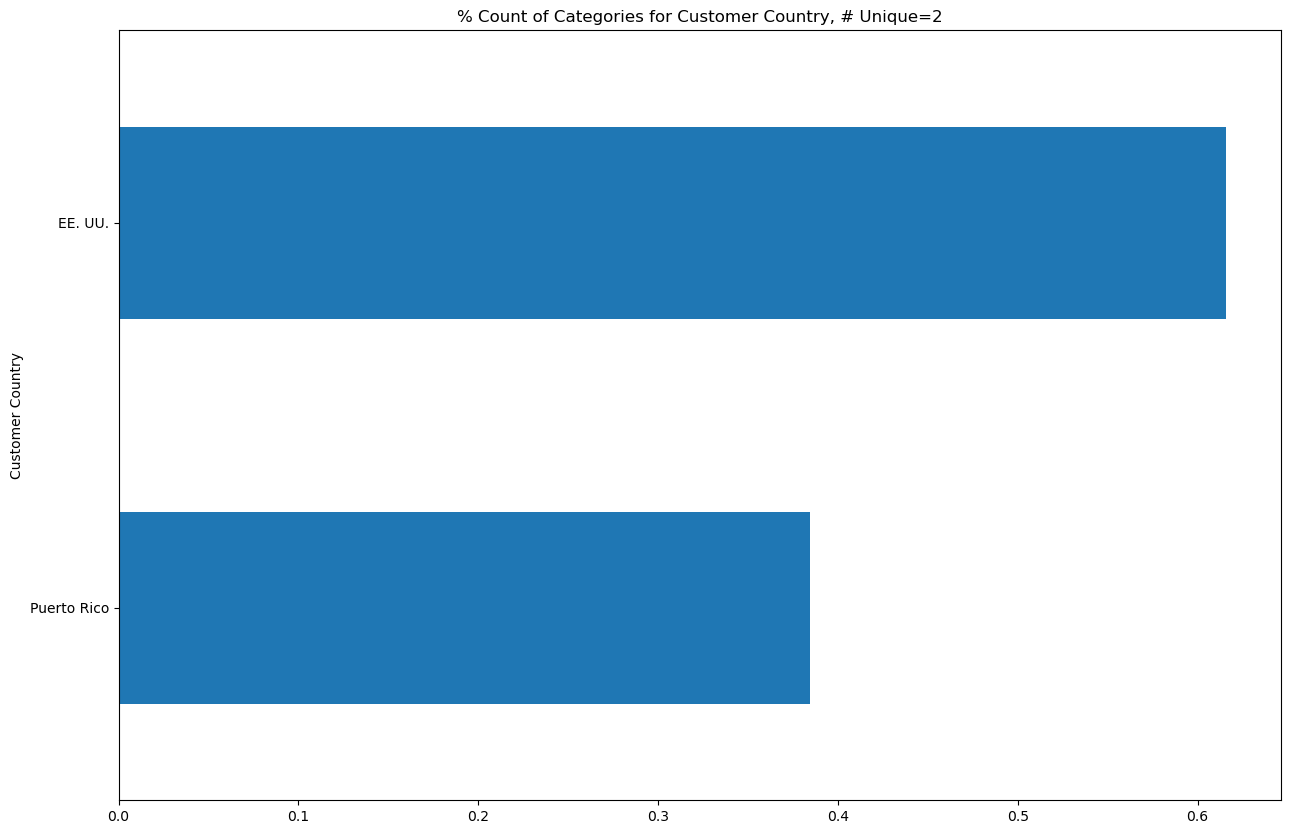

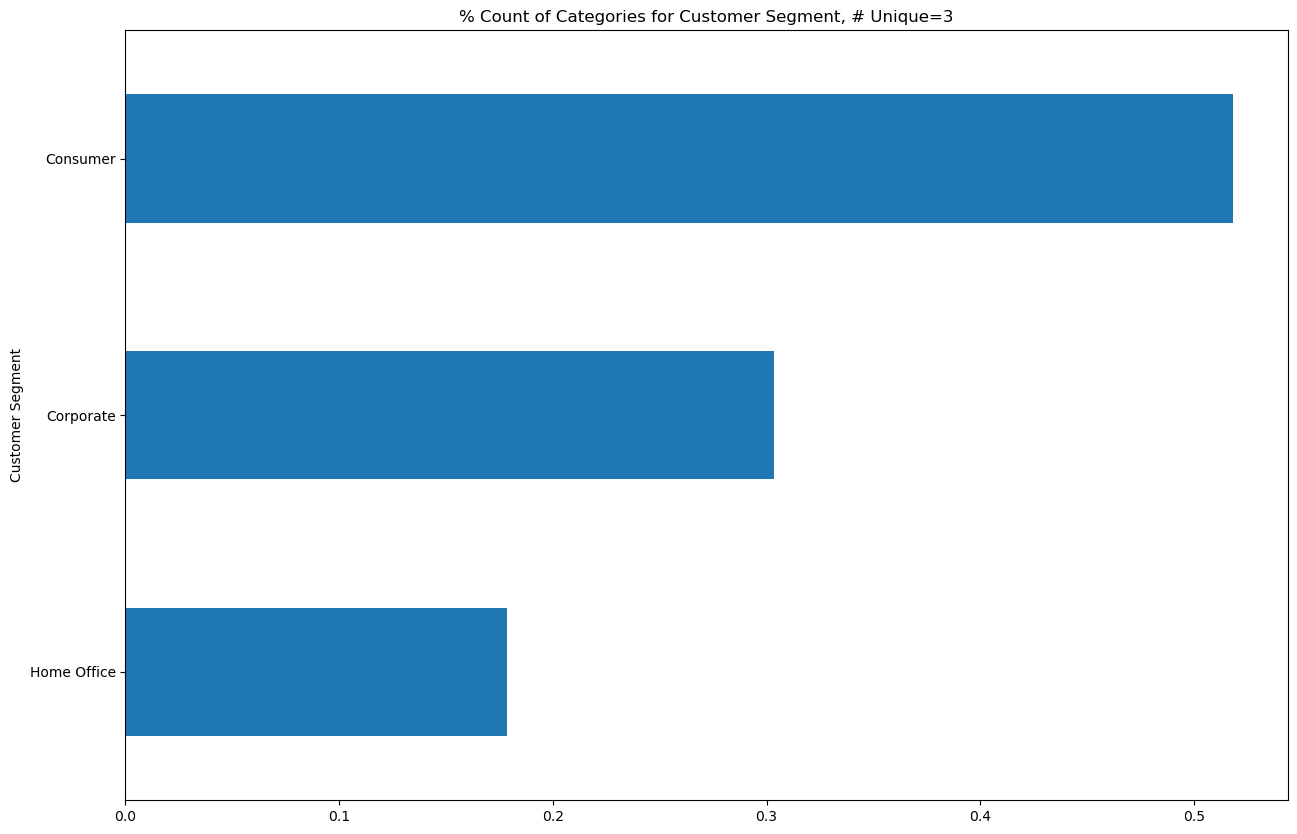

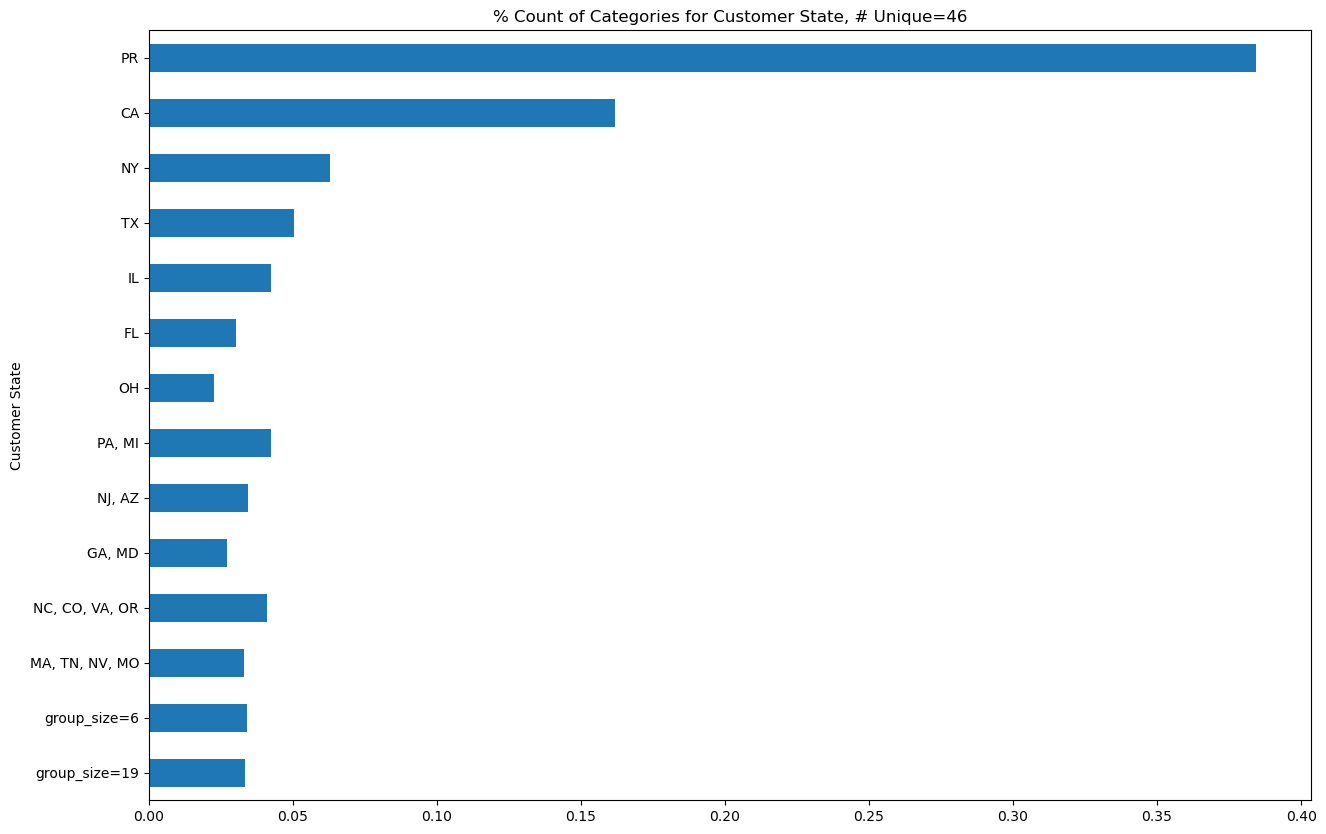

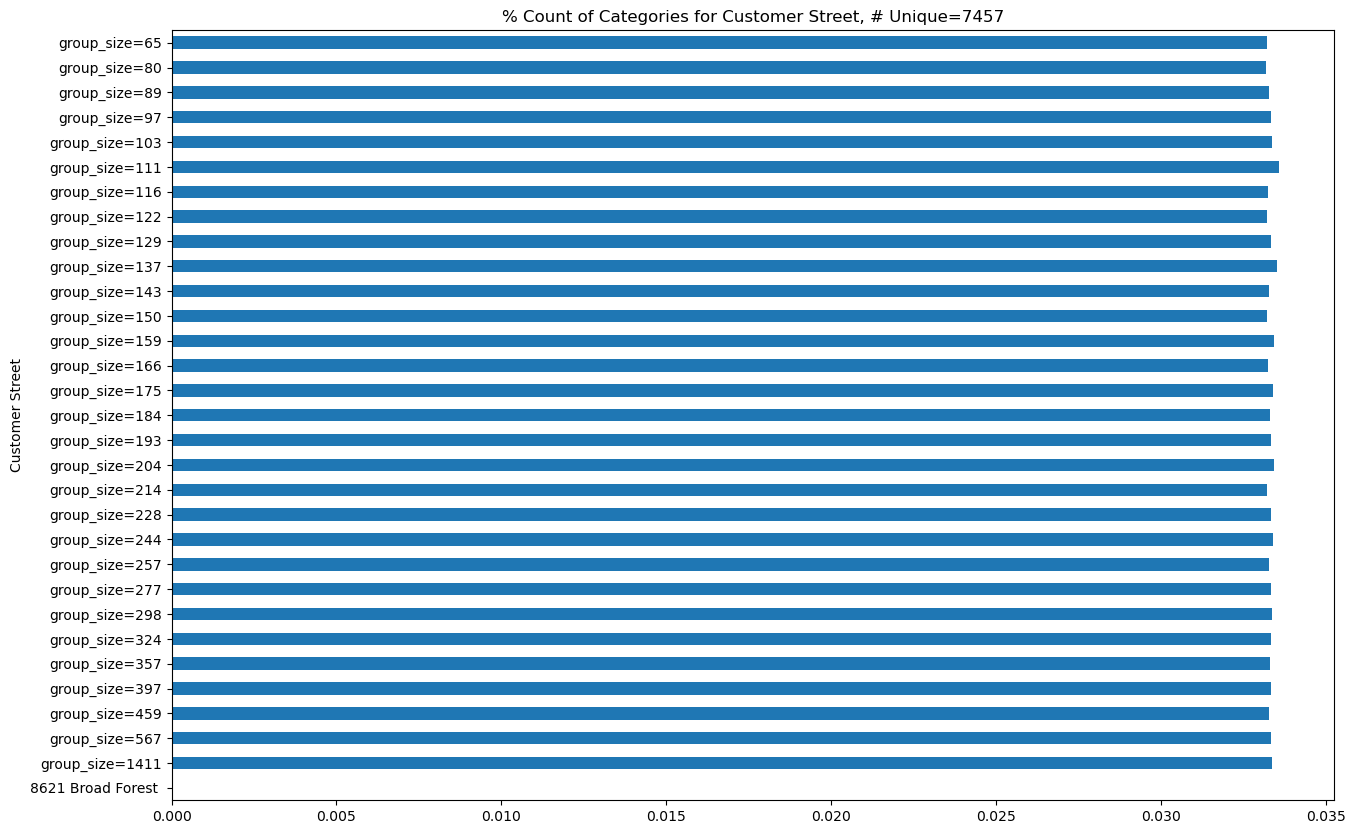

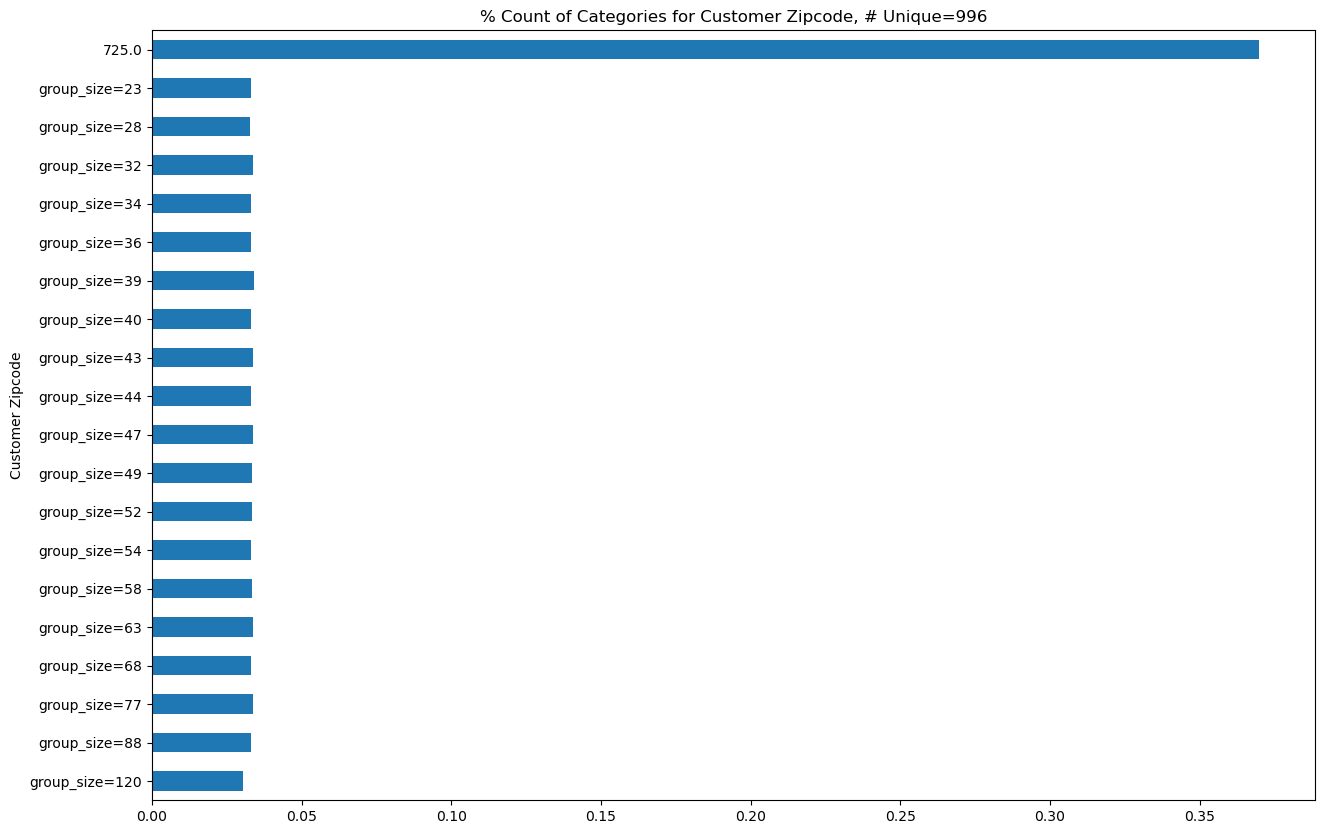

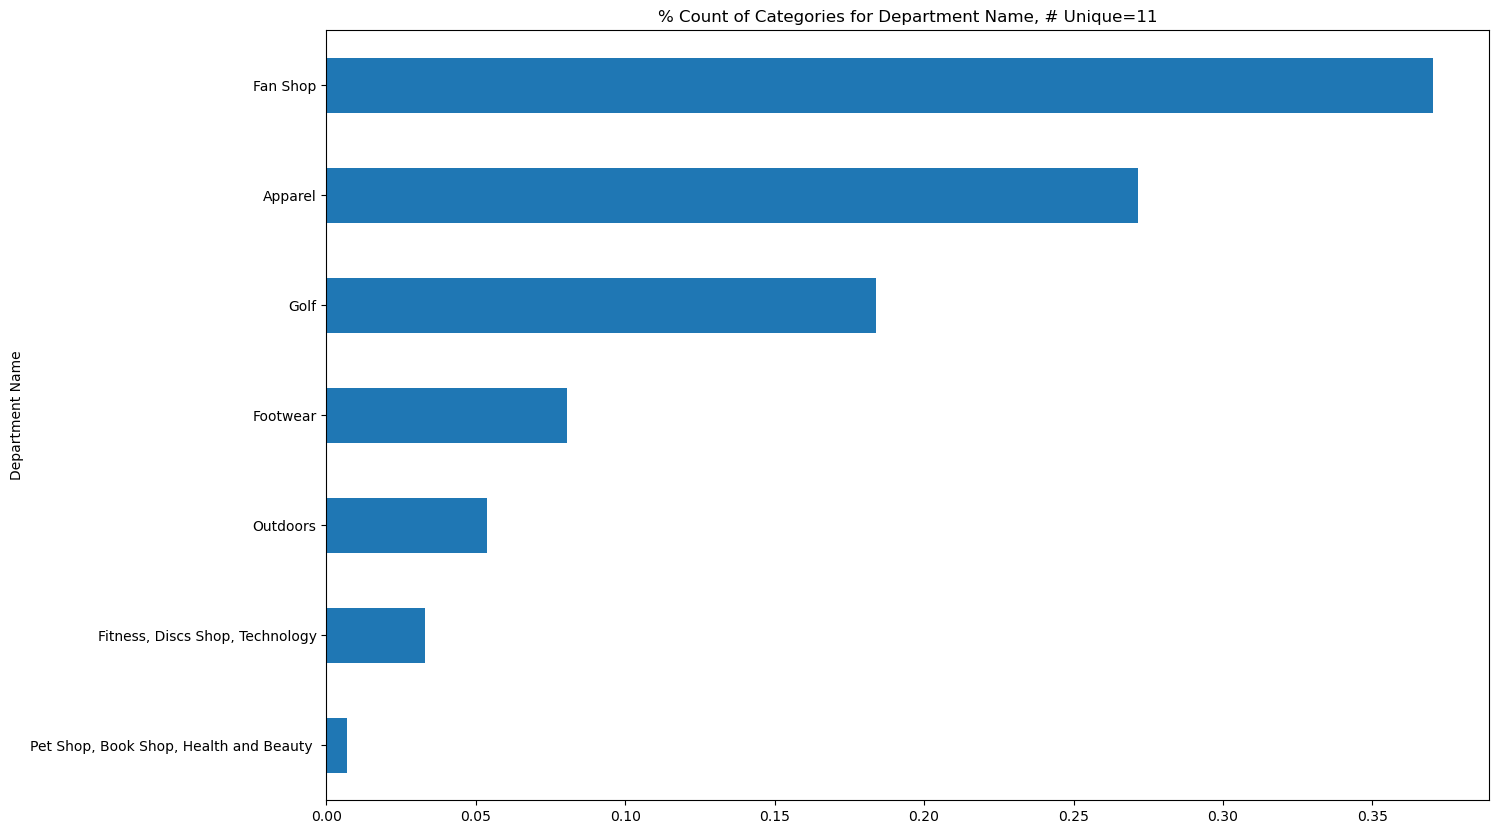

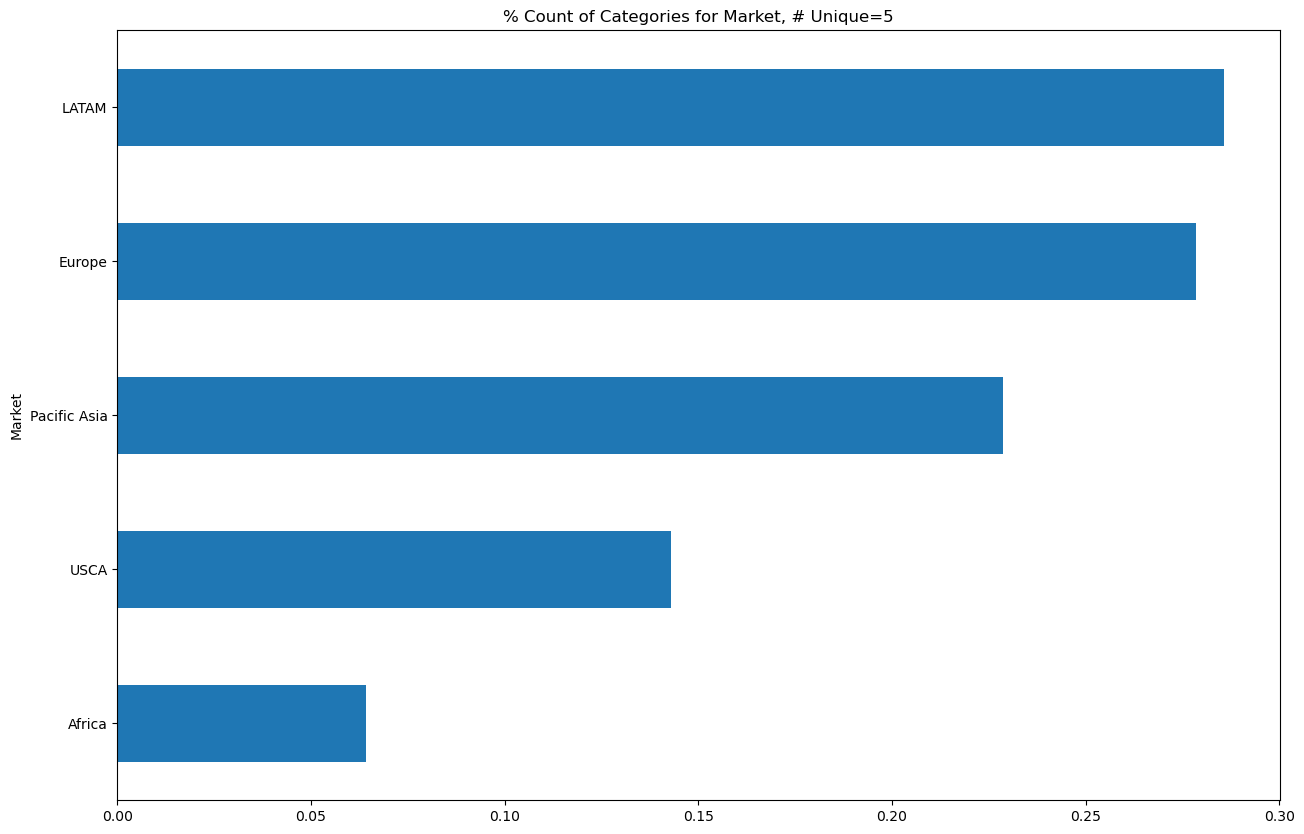

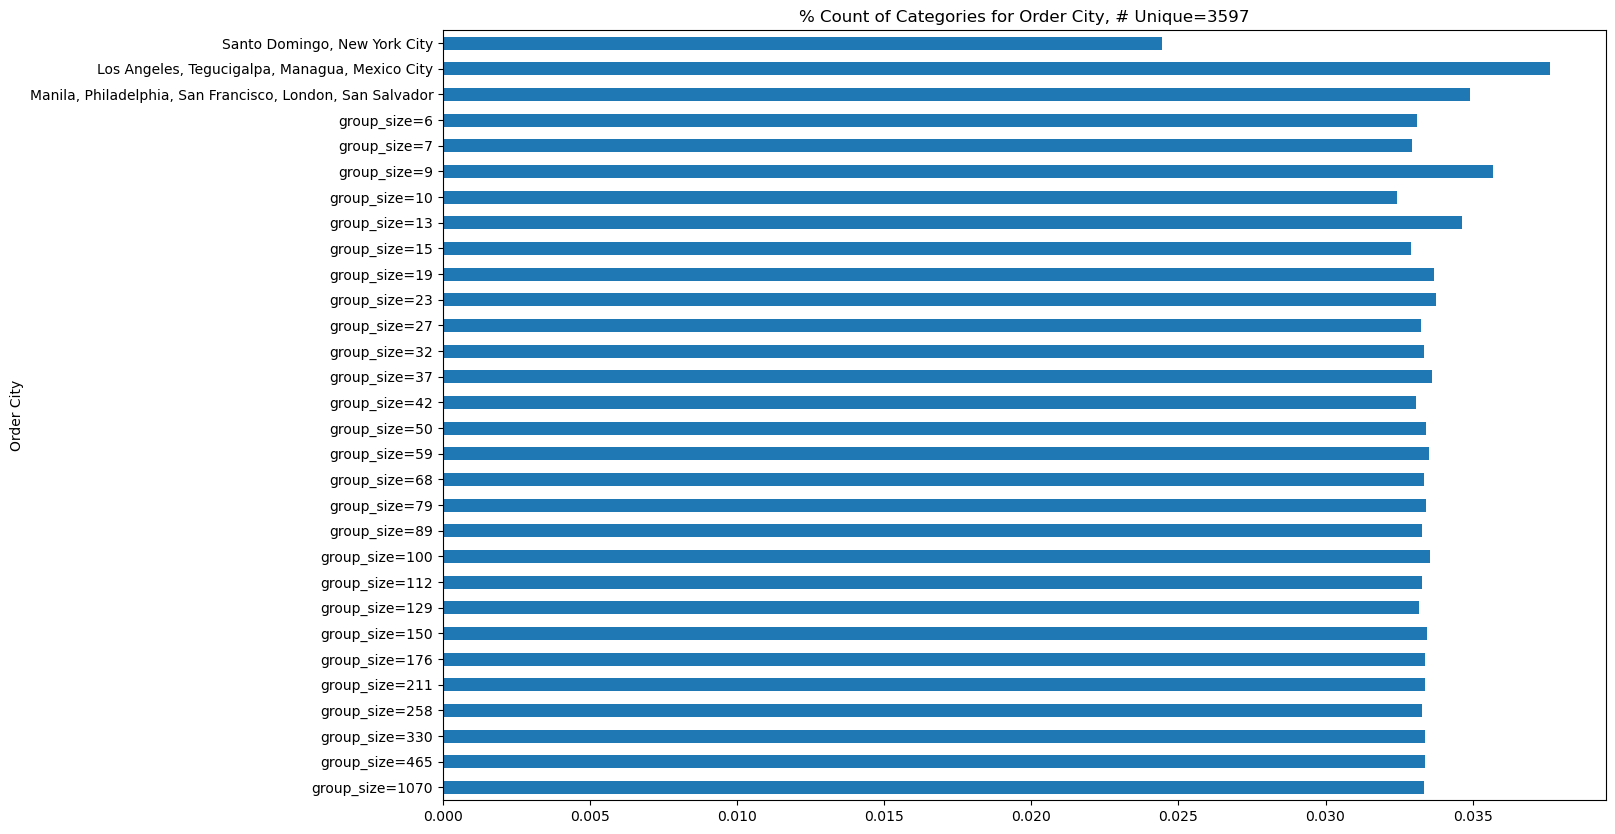

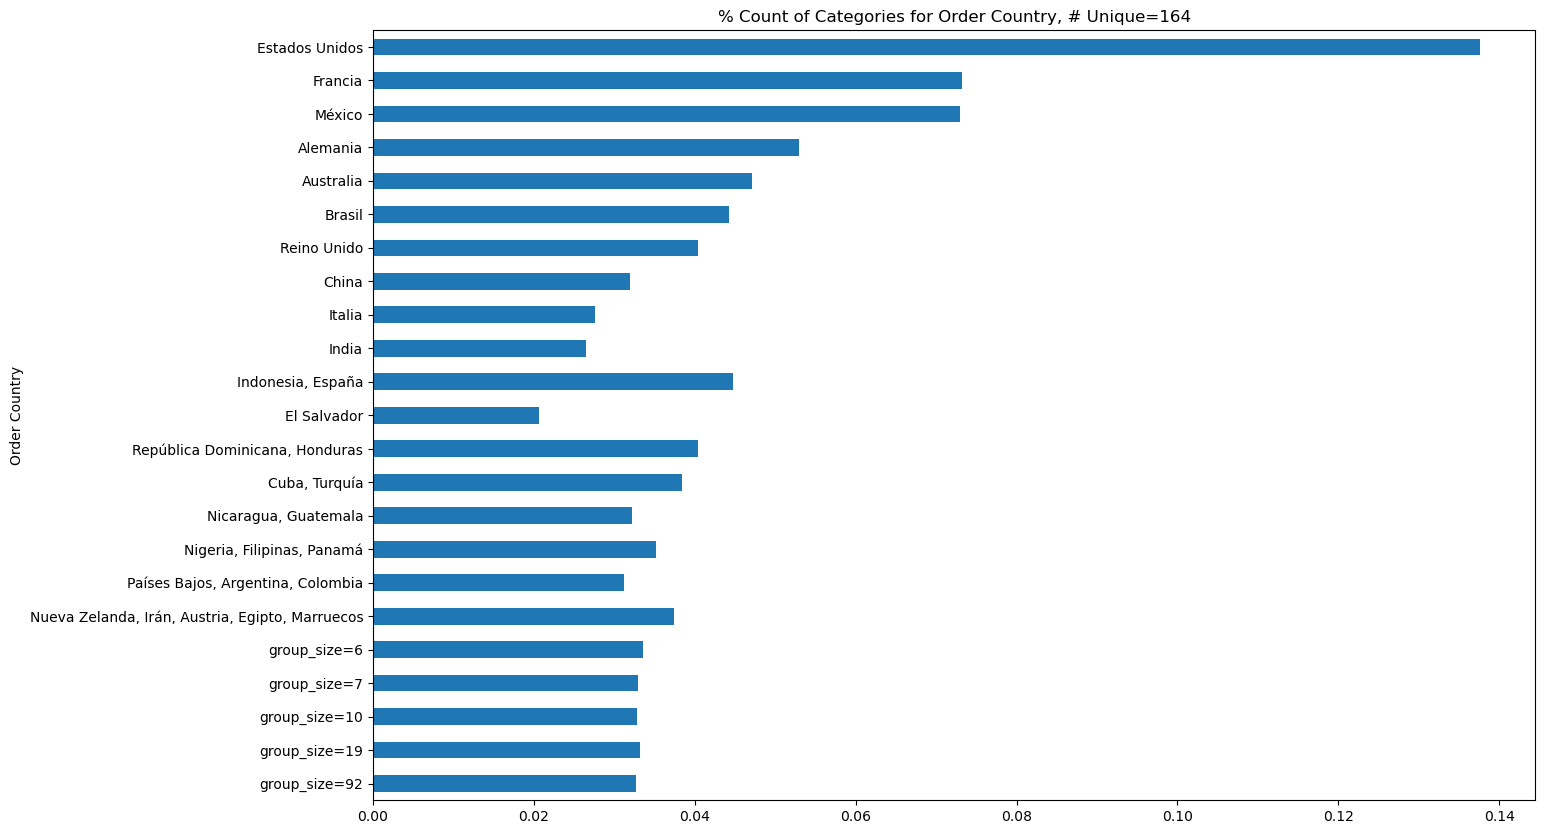

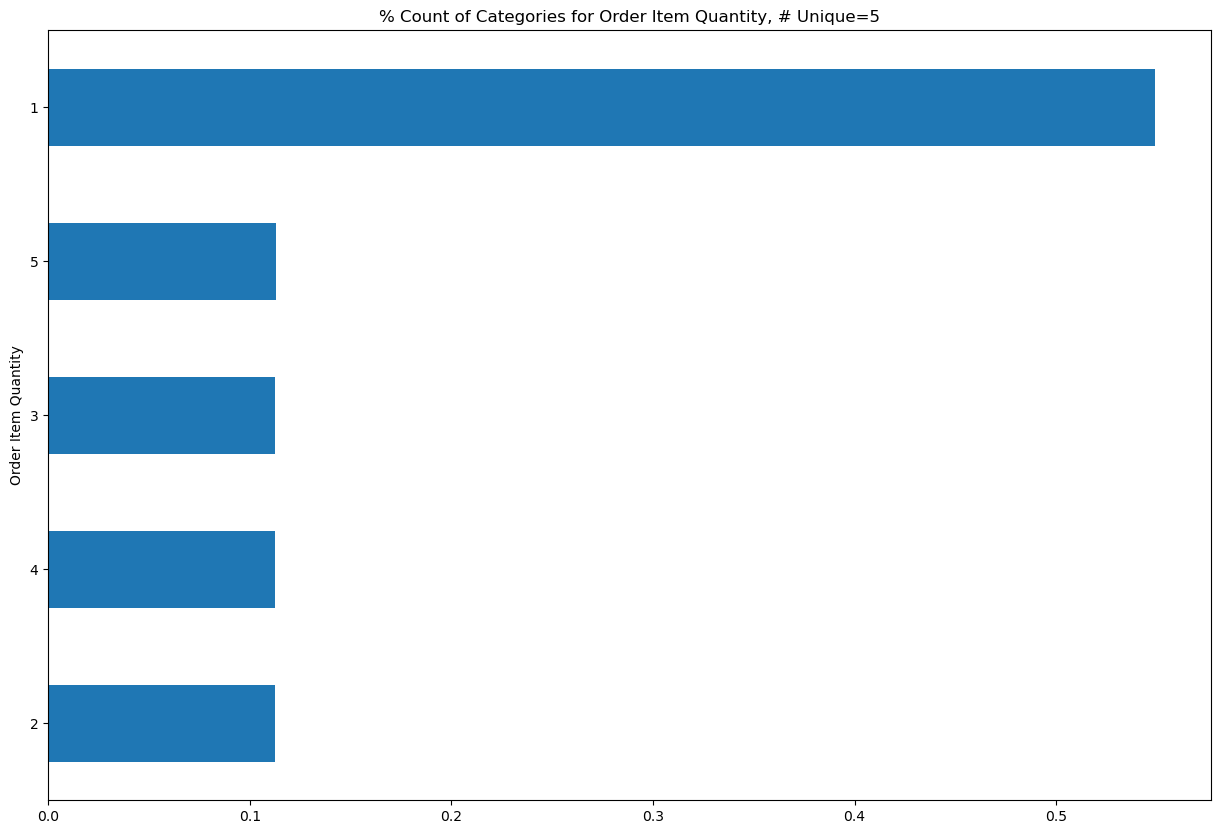

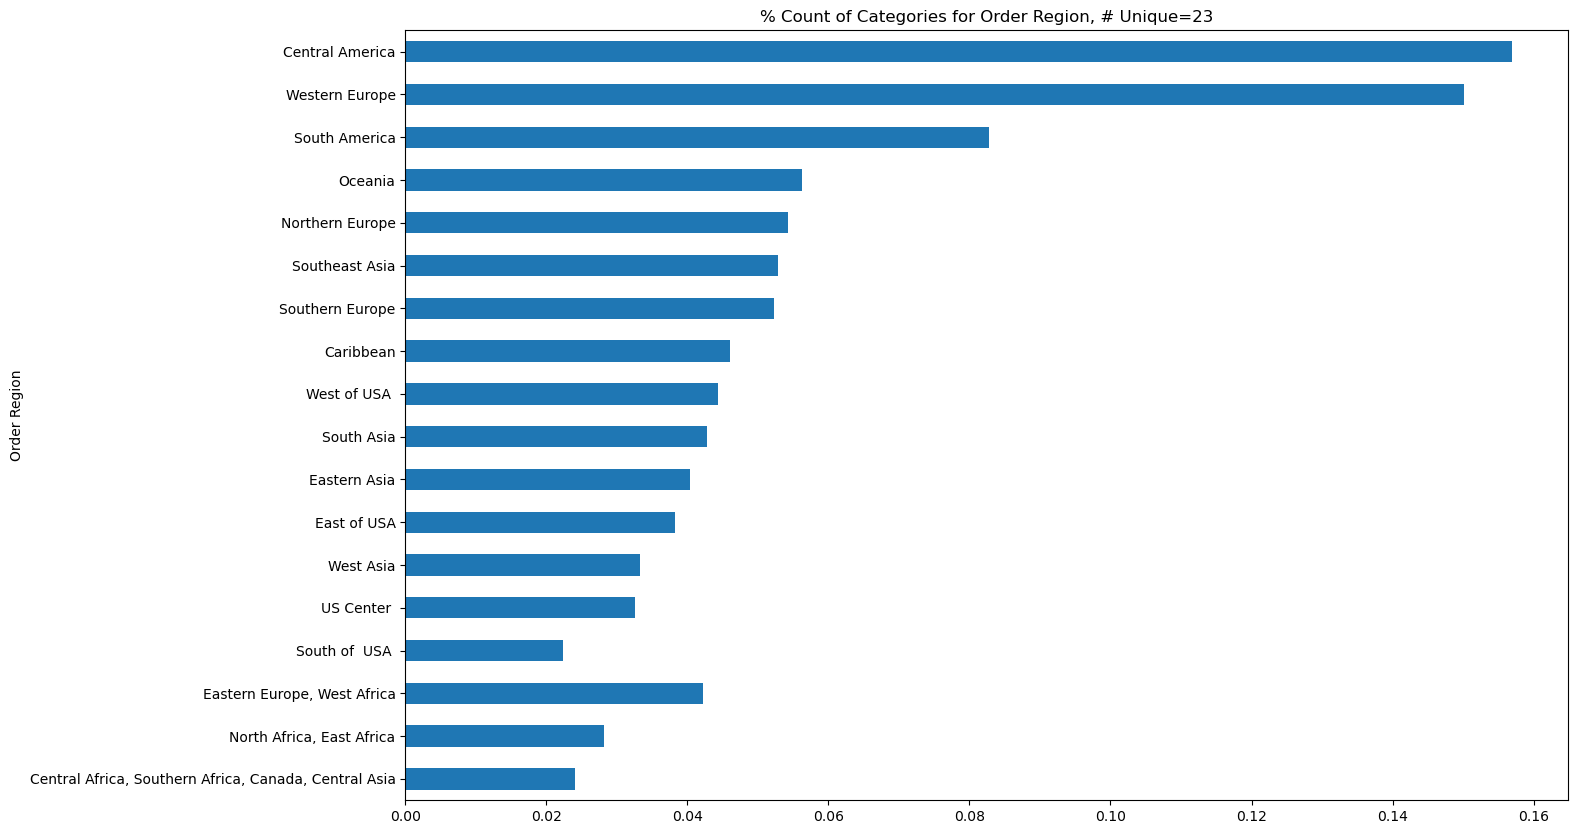

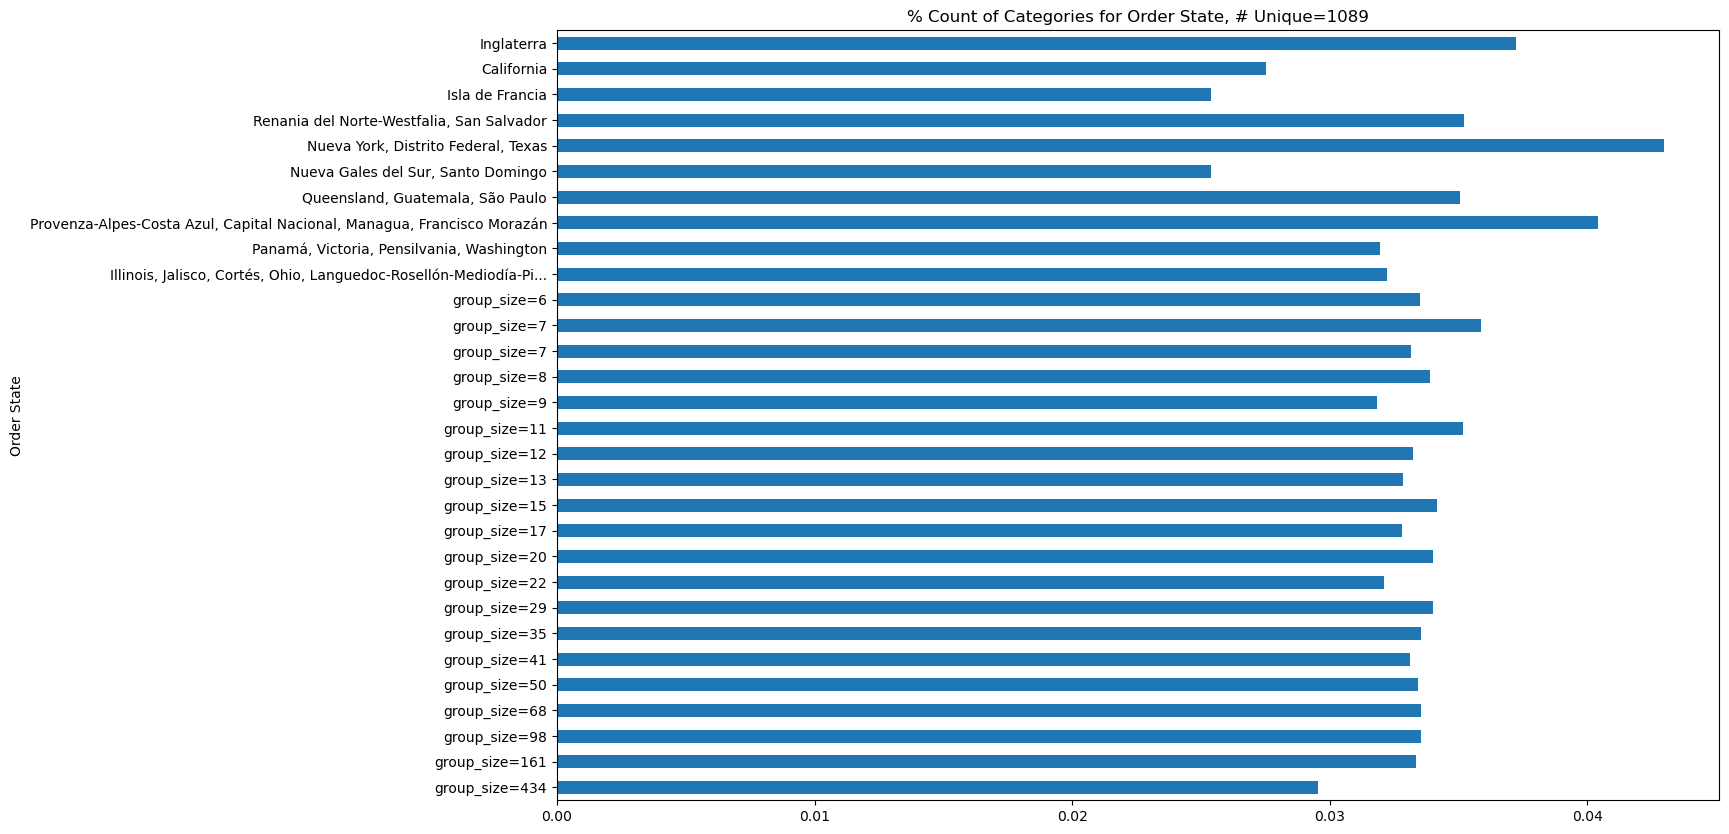

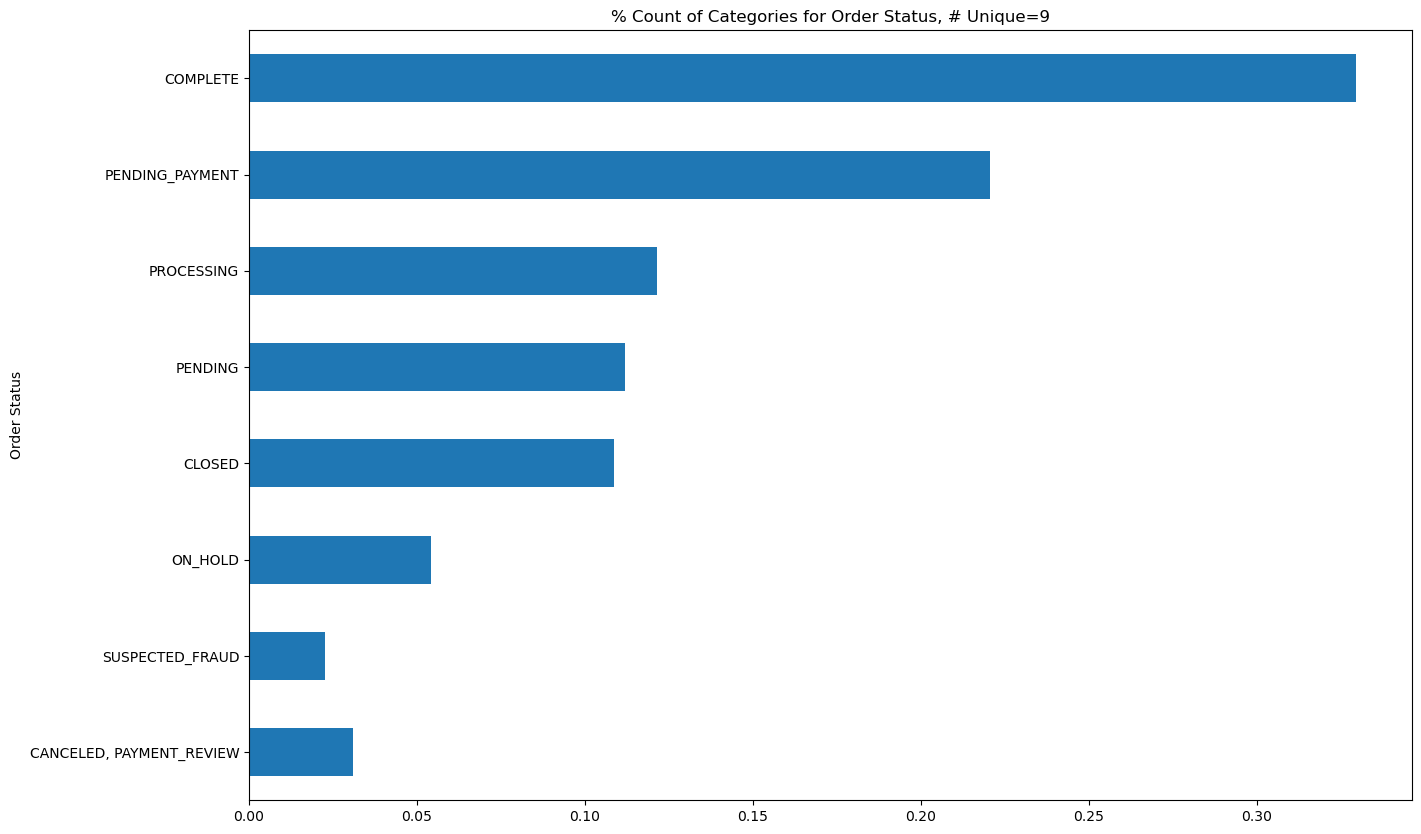

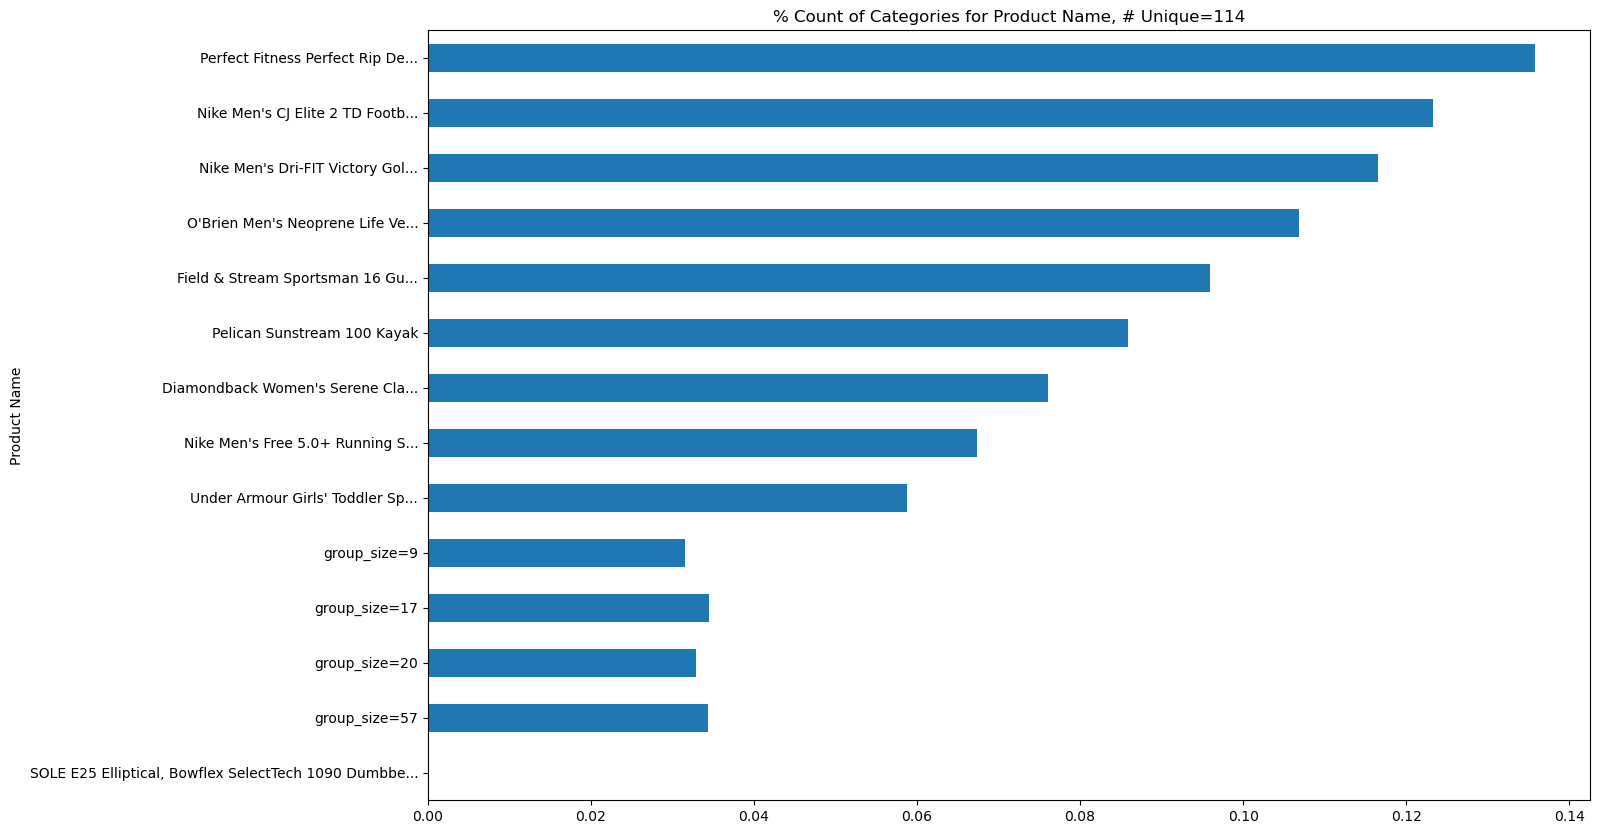

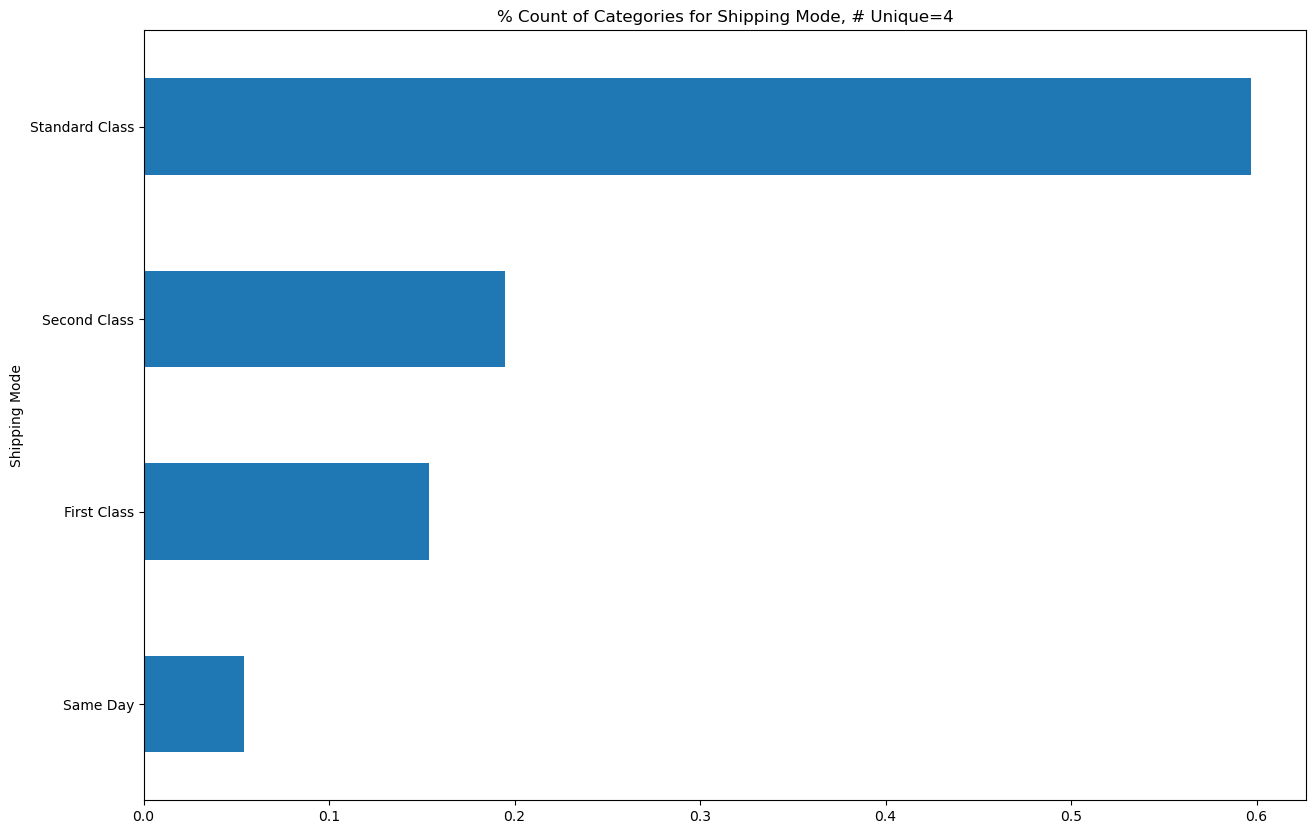

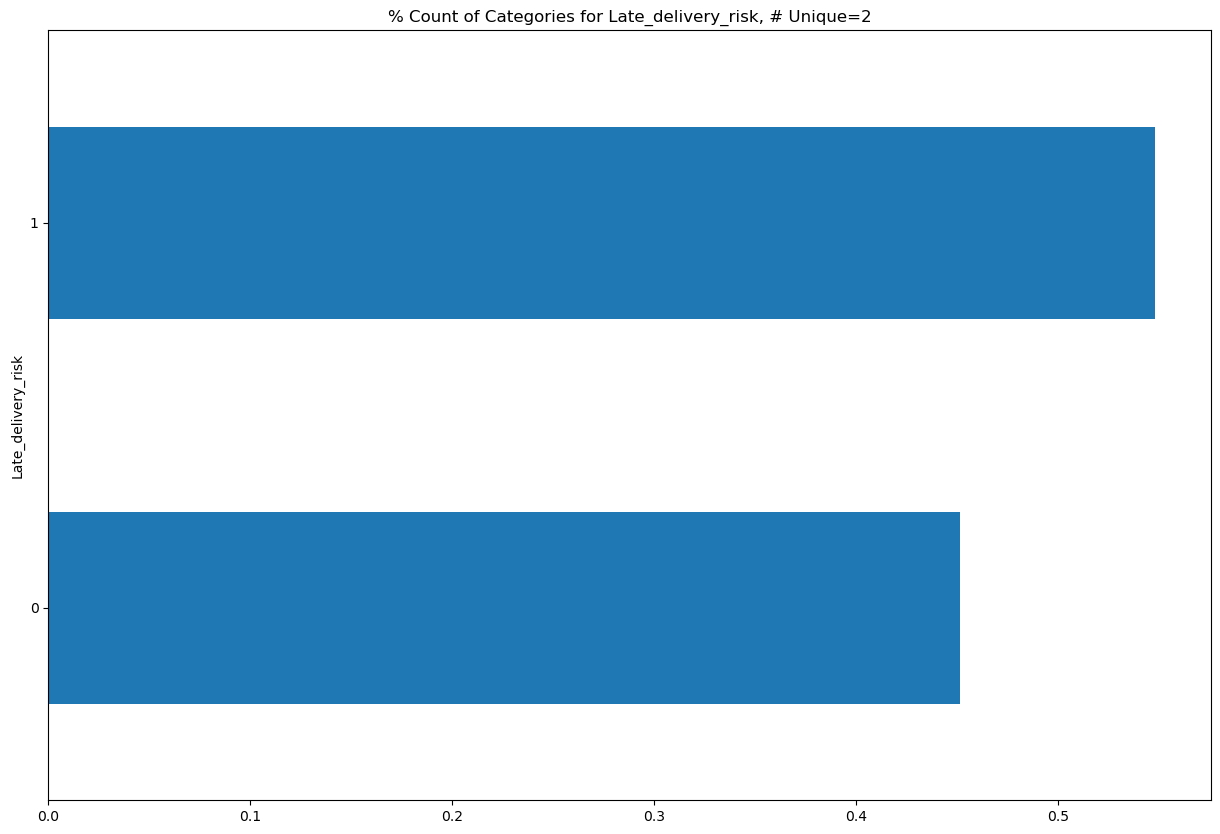

In [9]:
dta.plot_categ_stats();

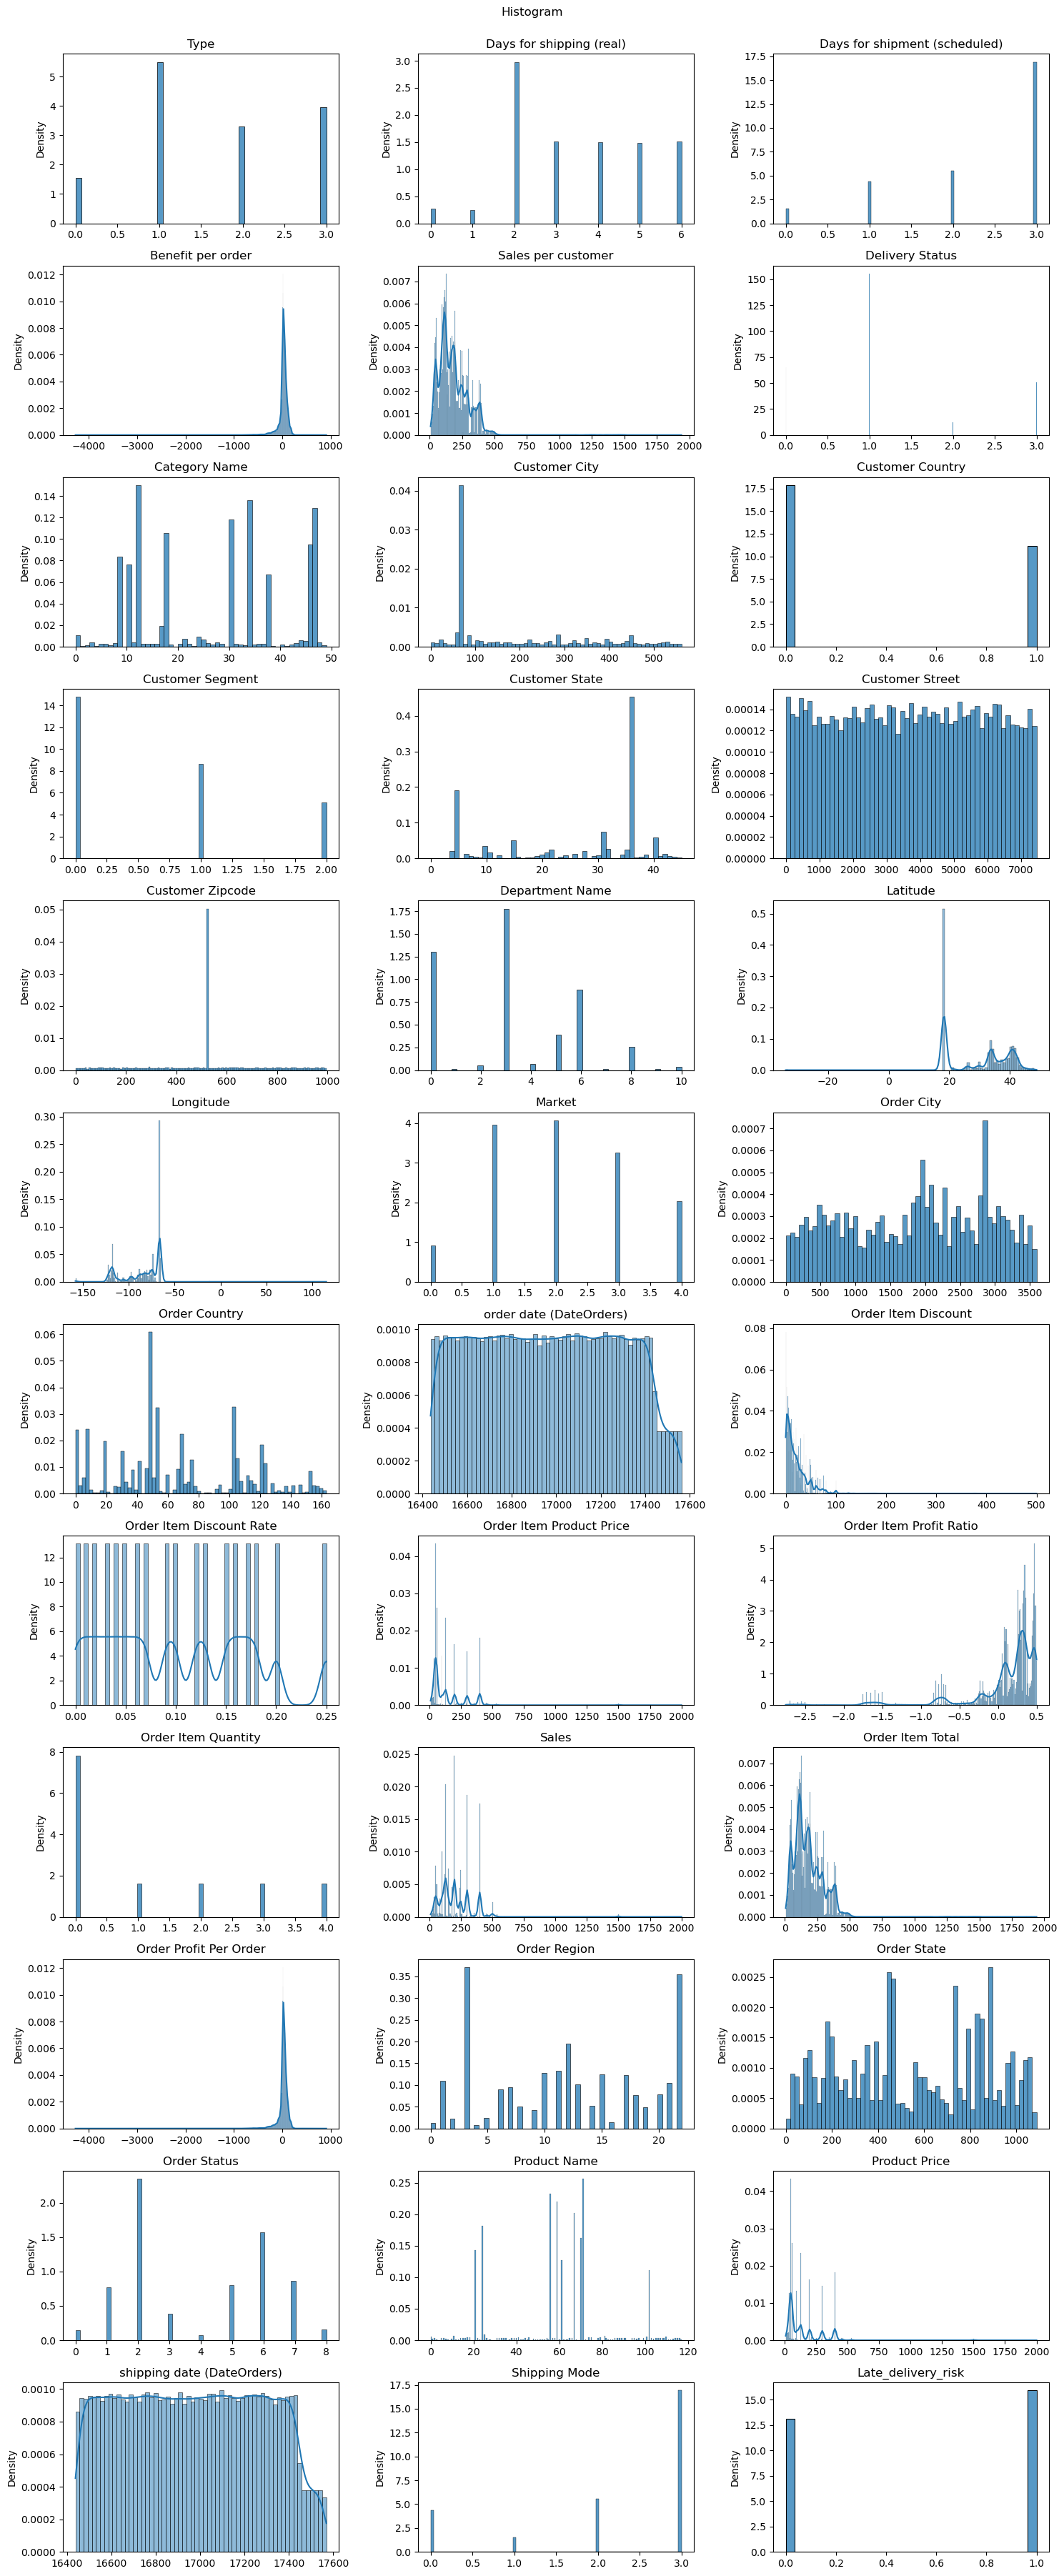

In [10]:
dta.dist_plot();

 80%|████████████████████████████████▉        | 536/666 [00:13<00:03, 34.63it/s]/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
100%|█████████████████████████████████████████| 666/666 [00:17<00:00, 37.72it/s]


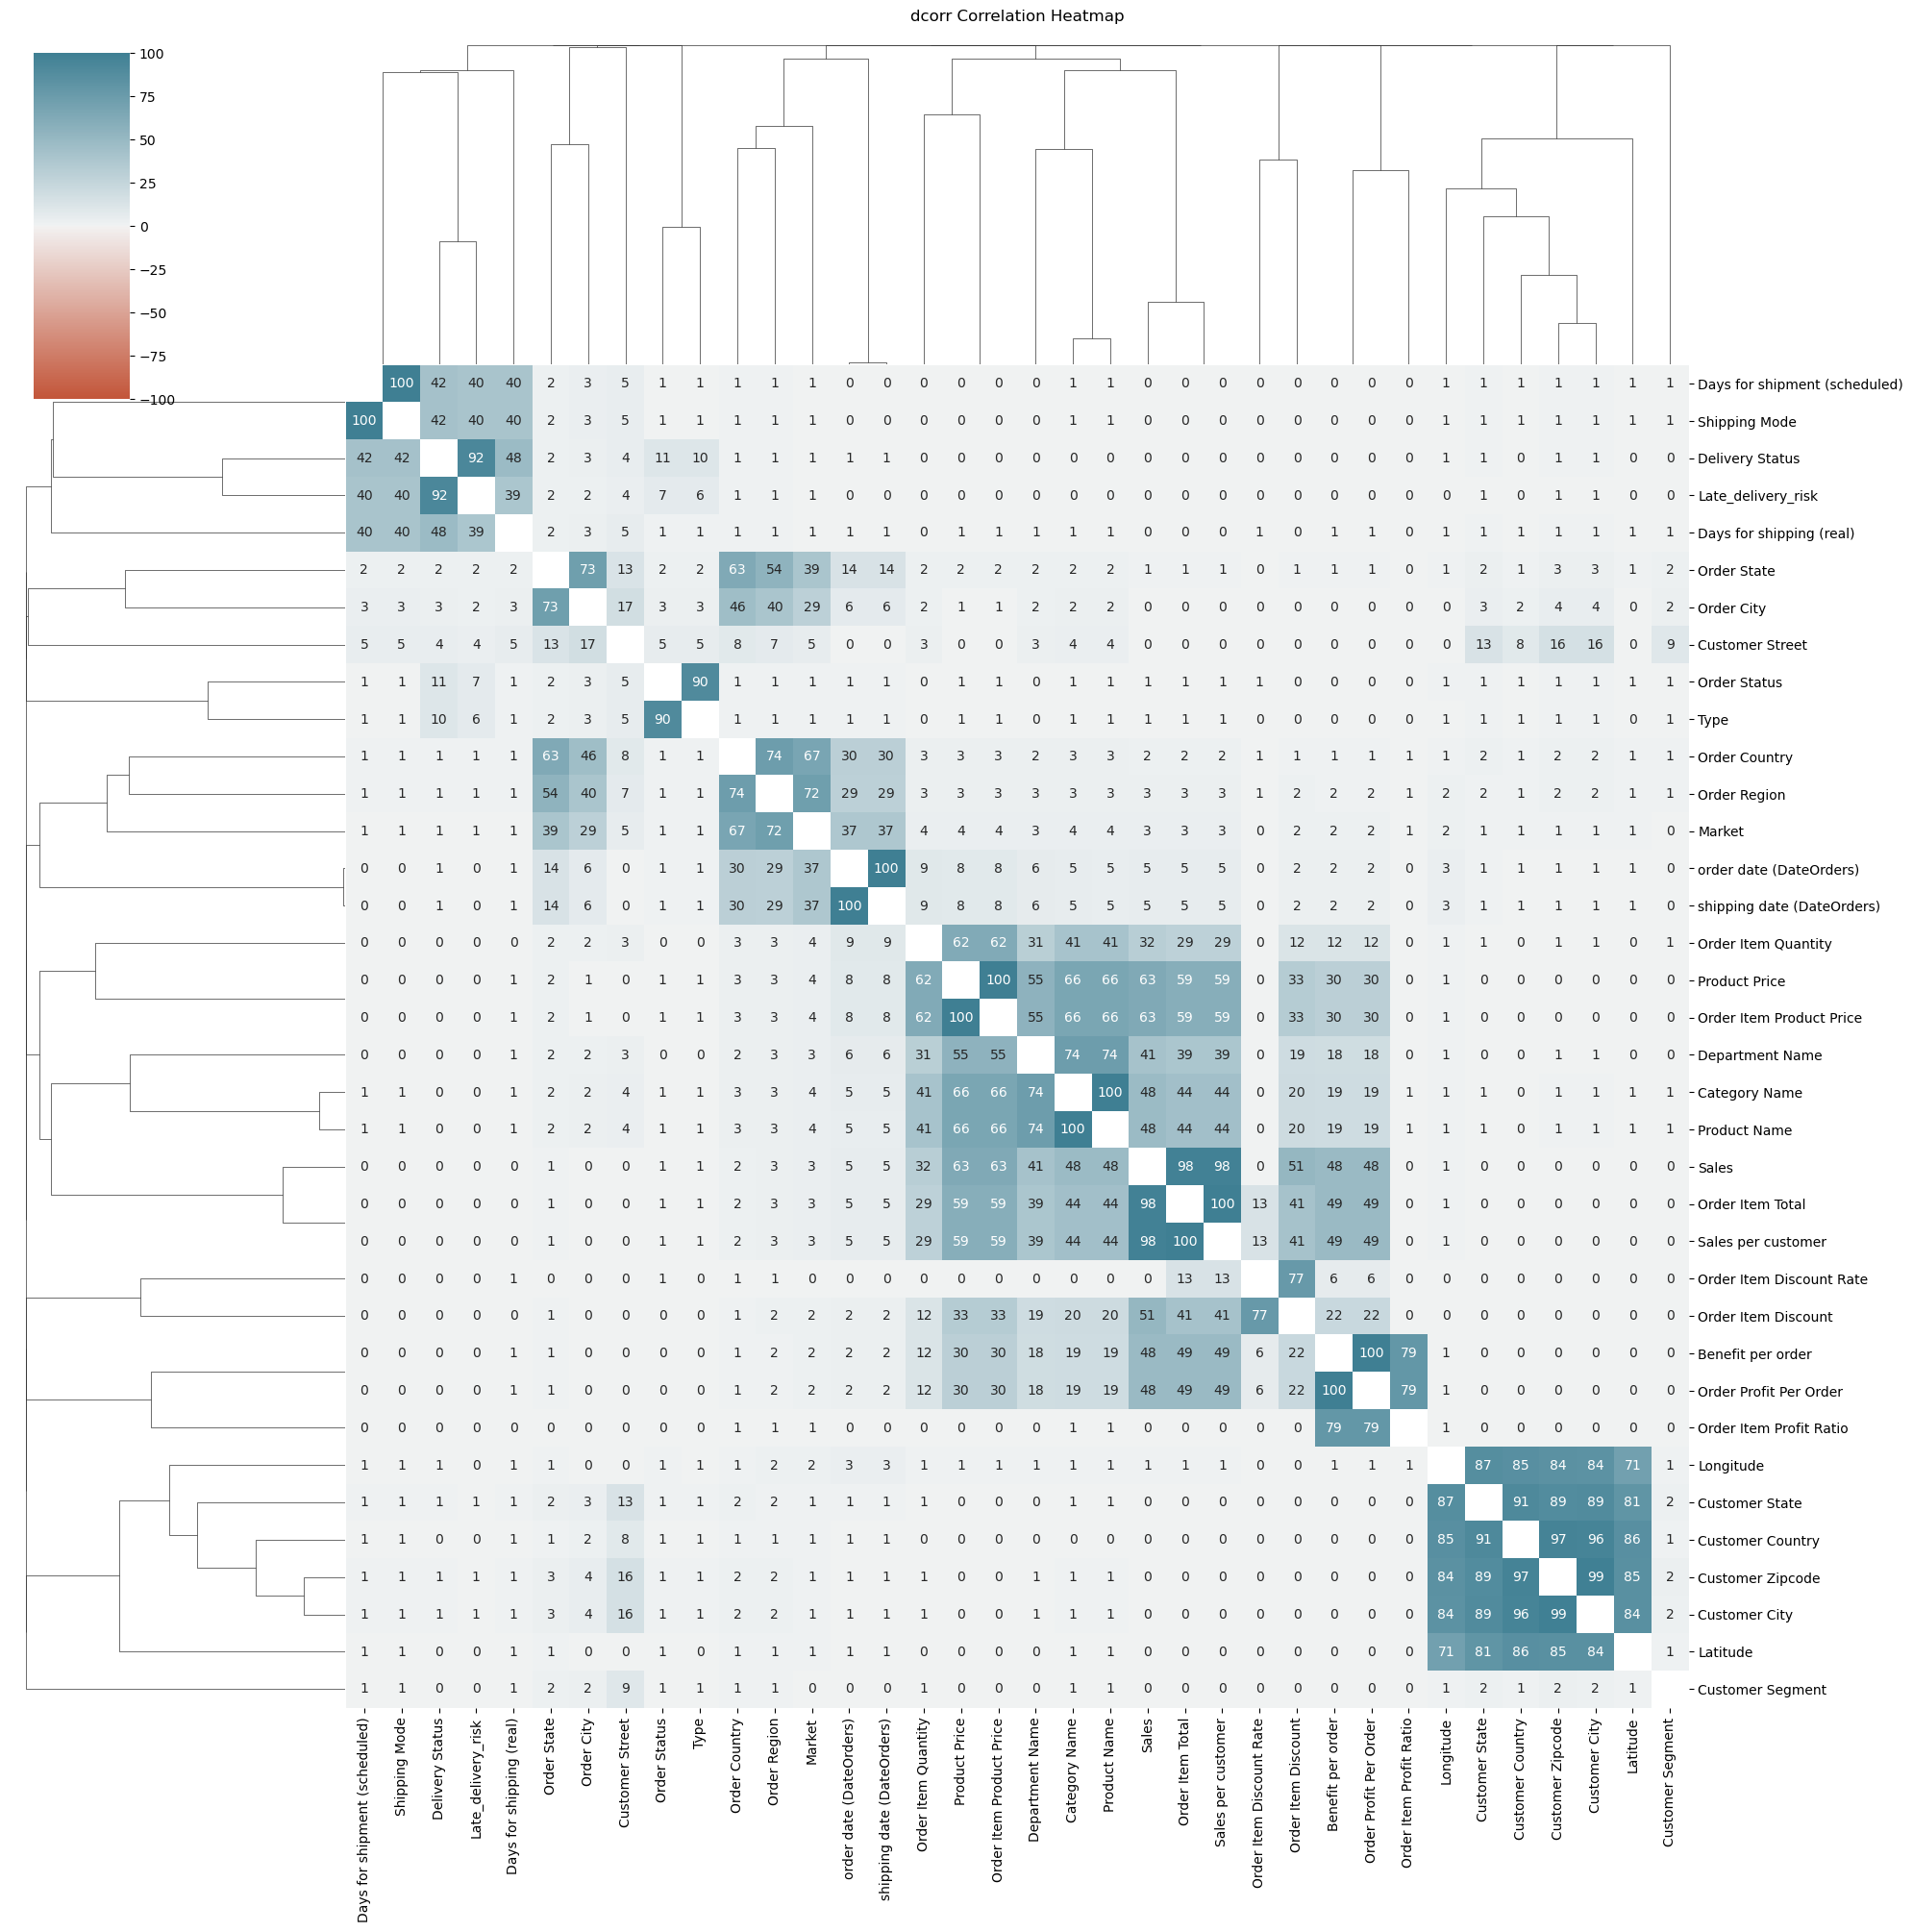

In [11]:
dta.corr_heatmap(corr_method='dcorr', figsize=(20, 20), cluster=True);

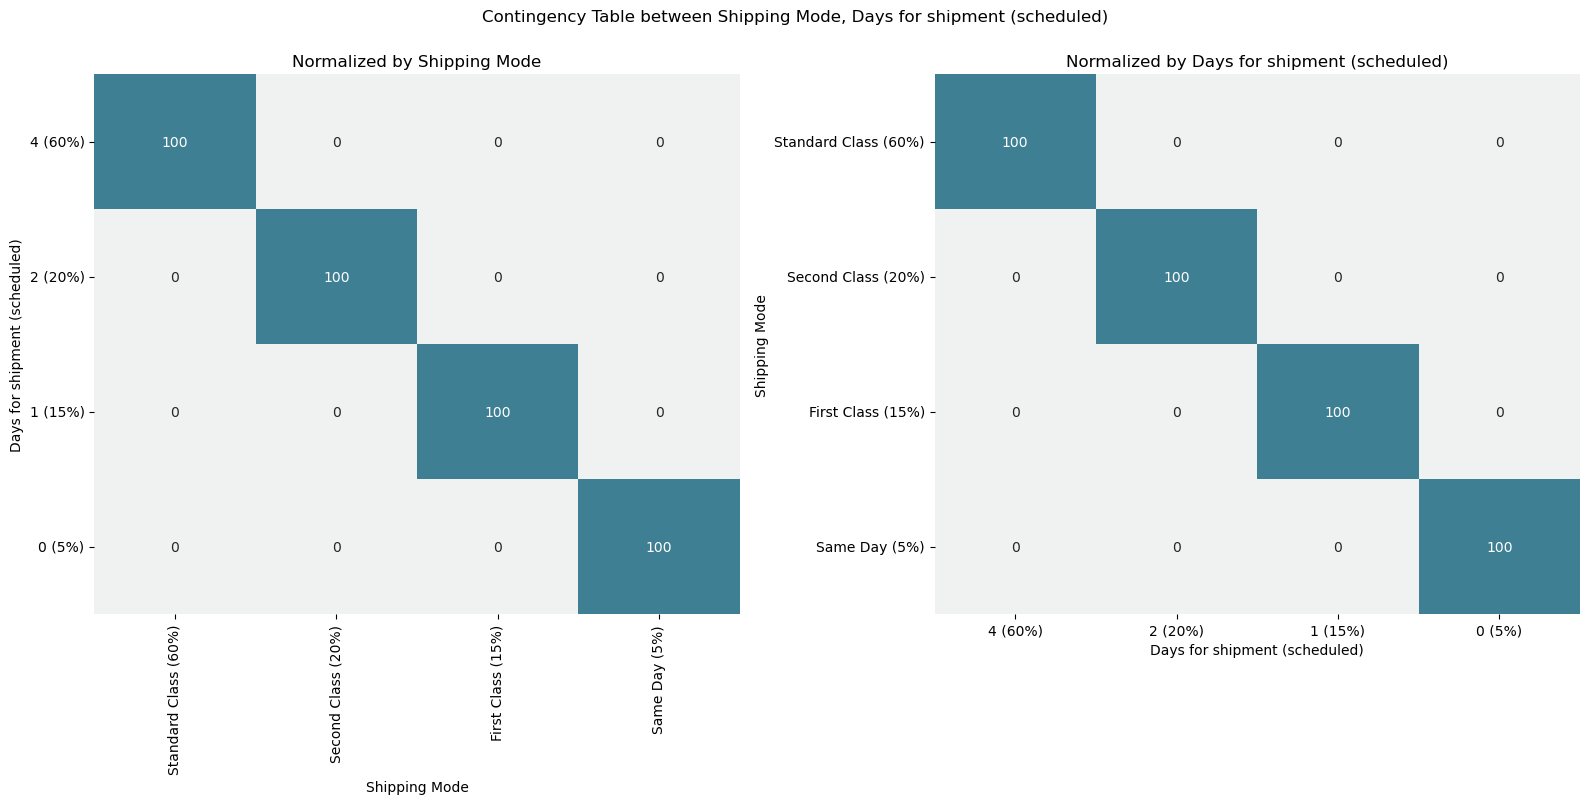

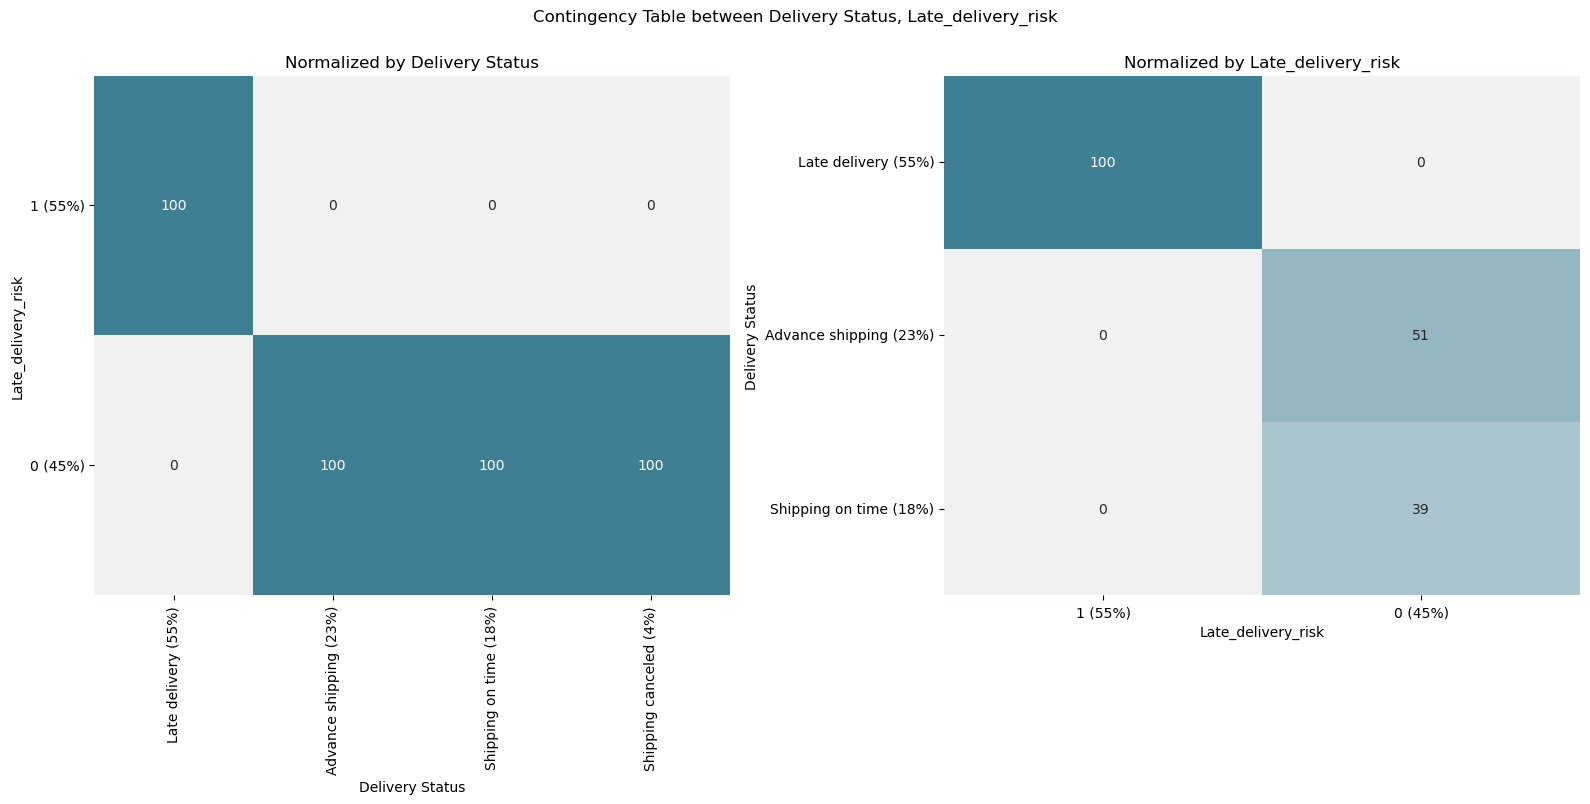

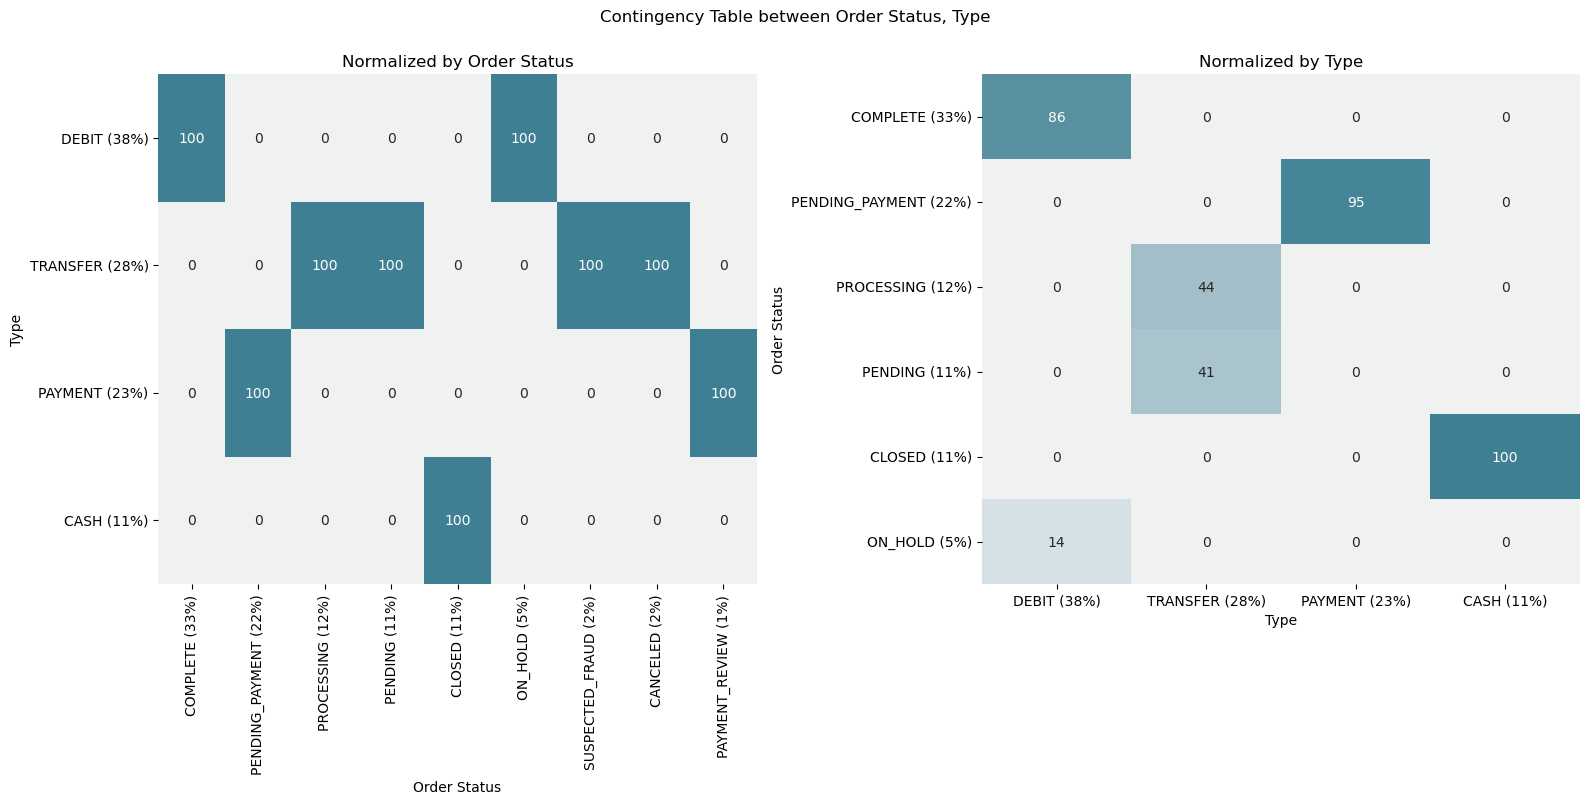

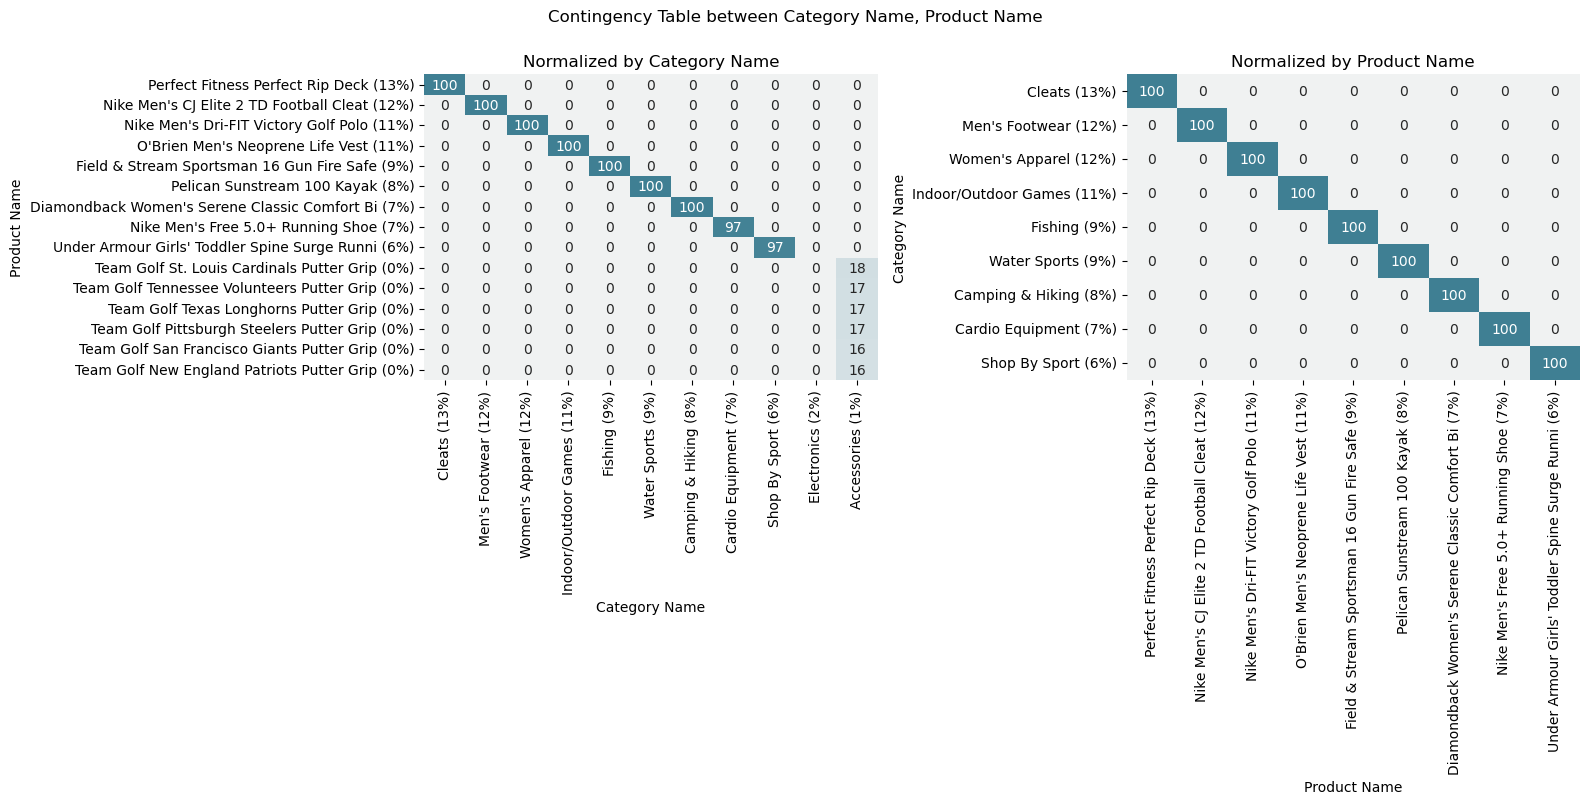

In [12]:
dta.plot_contingency('Shipping Mode', 'Days for shipment (scheduled)');
dta.plot_contingency('Delivery Status', 'Late_delivery_risk');
dta.plot_contingency('Order Status', 'Type');
dta.plot_contingency('Category Name', 'Product Name');

1. ```Days for shipment (scheduled)```is due to ```Shipping Mode```
2. Should create ```Shipping Date``` - ```Order Date``` = ```Days for shipping (real)```
3. ```Benefit per order``` = ```Order Profit Per Order```
4. ```Order Item Total``` =  ```Sales per customer```
5. ```Product Price``` = ```Order Item Product Price```
6. ```Sales``` = ```Product Price``` * ```Order Item Quantity```
7. ```Sales per customer``` = ```Sales``` - ```Order Item Discount```
8. ```Order Item Discount Rate``` = (```Order Item Discount``` / ```Sales```).round(2)
9. ```Order Item Profit Ratio``` = (```Benefit per order``` / ```Sales per customer```).round(2)
10. ```Type``` is contained by ```Order Status```
11. ```Late_delivery_risk``` is contained by ```Delivery Status```
12. ```Category Name``` = ```Product Name```
13. ```Market``` < ```Order Region``` < ```Order Country``` < ```Order State``` < ```Order City```, only keep to at most ```State``` level

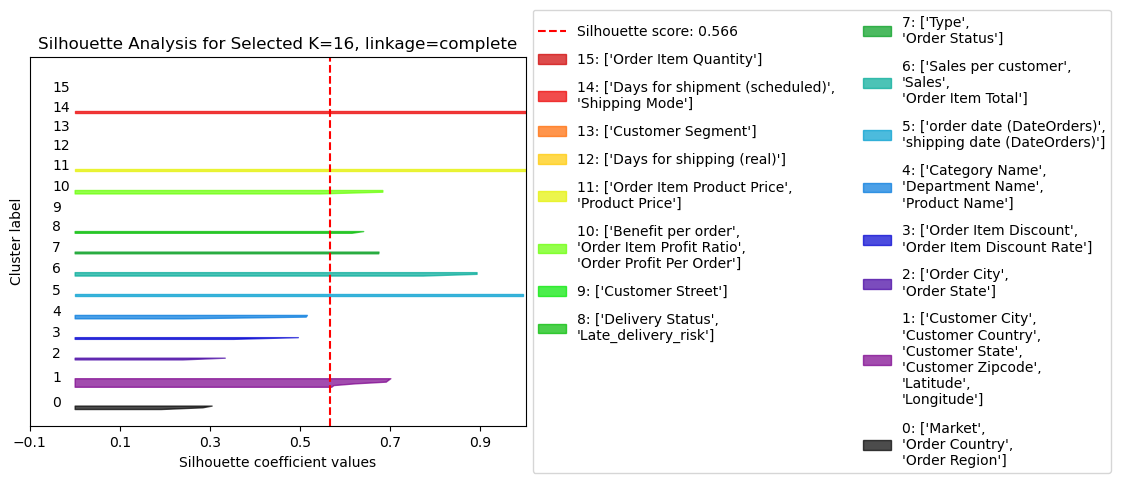

In [16]:
dta.cluster_features();

### 2.1 Feature Engineering

In [20]:
df2 = df.copy()
# Knowing 'Delay' is equal to delivery status
# df2['Delay'] = df2['Days for shipping (real)'] - df2['Days for shipment (scheduled)']
df2 = df2.drop(columns=['Order Item Product Price',
                     'Order Item Discount', 'Order Profit Per Order',
                     'Sales', 'Benefit per order',
                     'Order Item Total', 'Sales per customer',
                       'shipping date (DateOrders)',
                       'Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 
                        'Product Name', 'Days for shipping (real)', 'Market',
                       'Order City', 
                        'Customer City', 'Customer Street', 'Customer Zipcode',
                       ])

100%|████████████████████████████████████████| 171/171 [00:00<00:00, 230.49it/s]


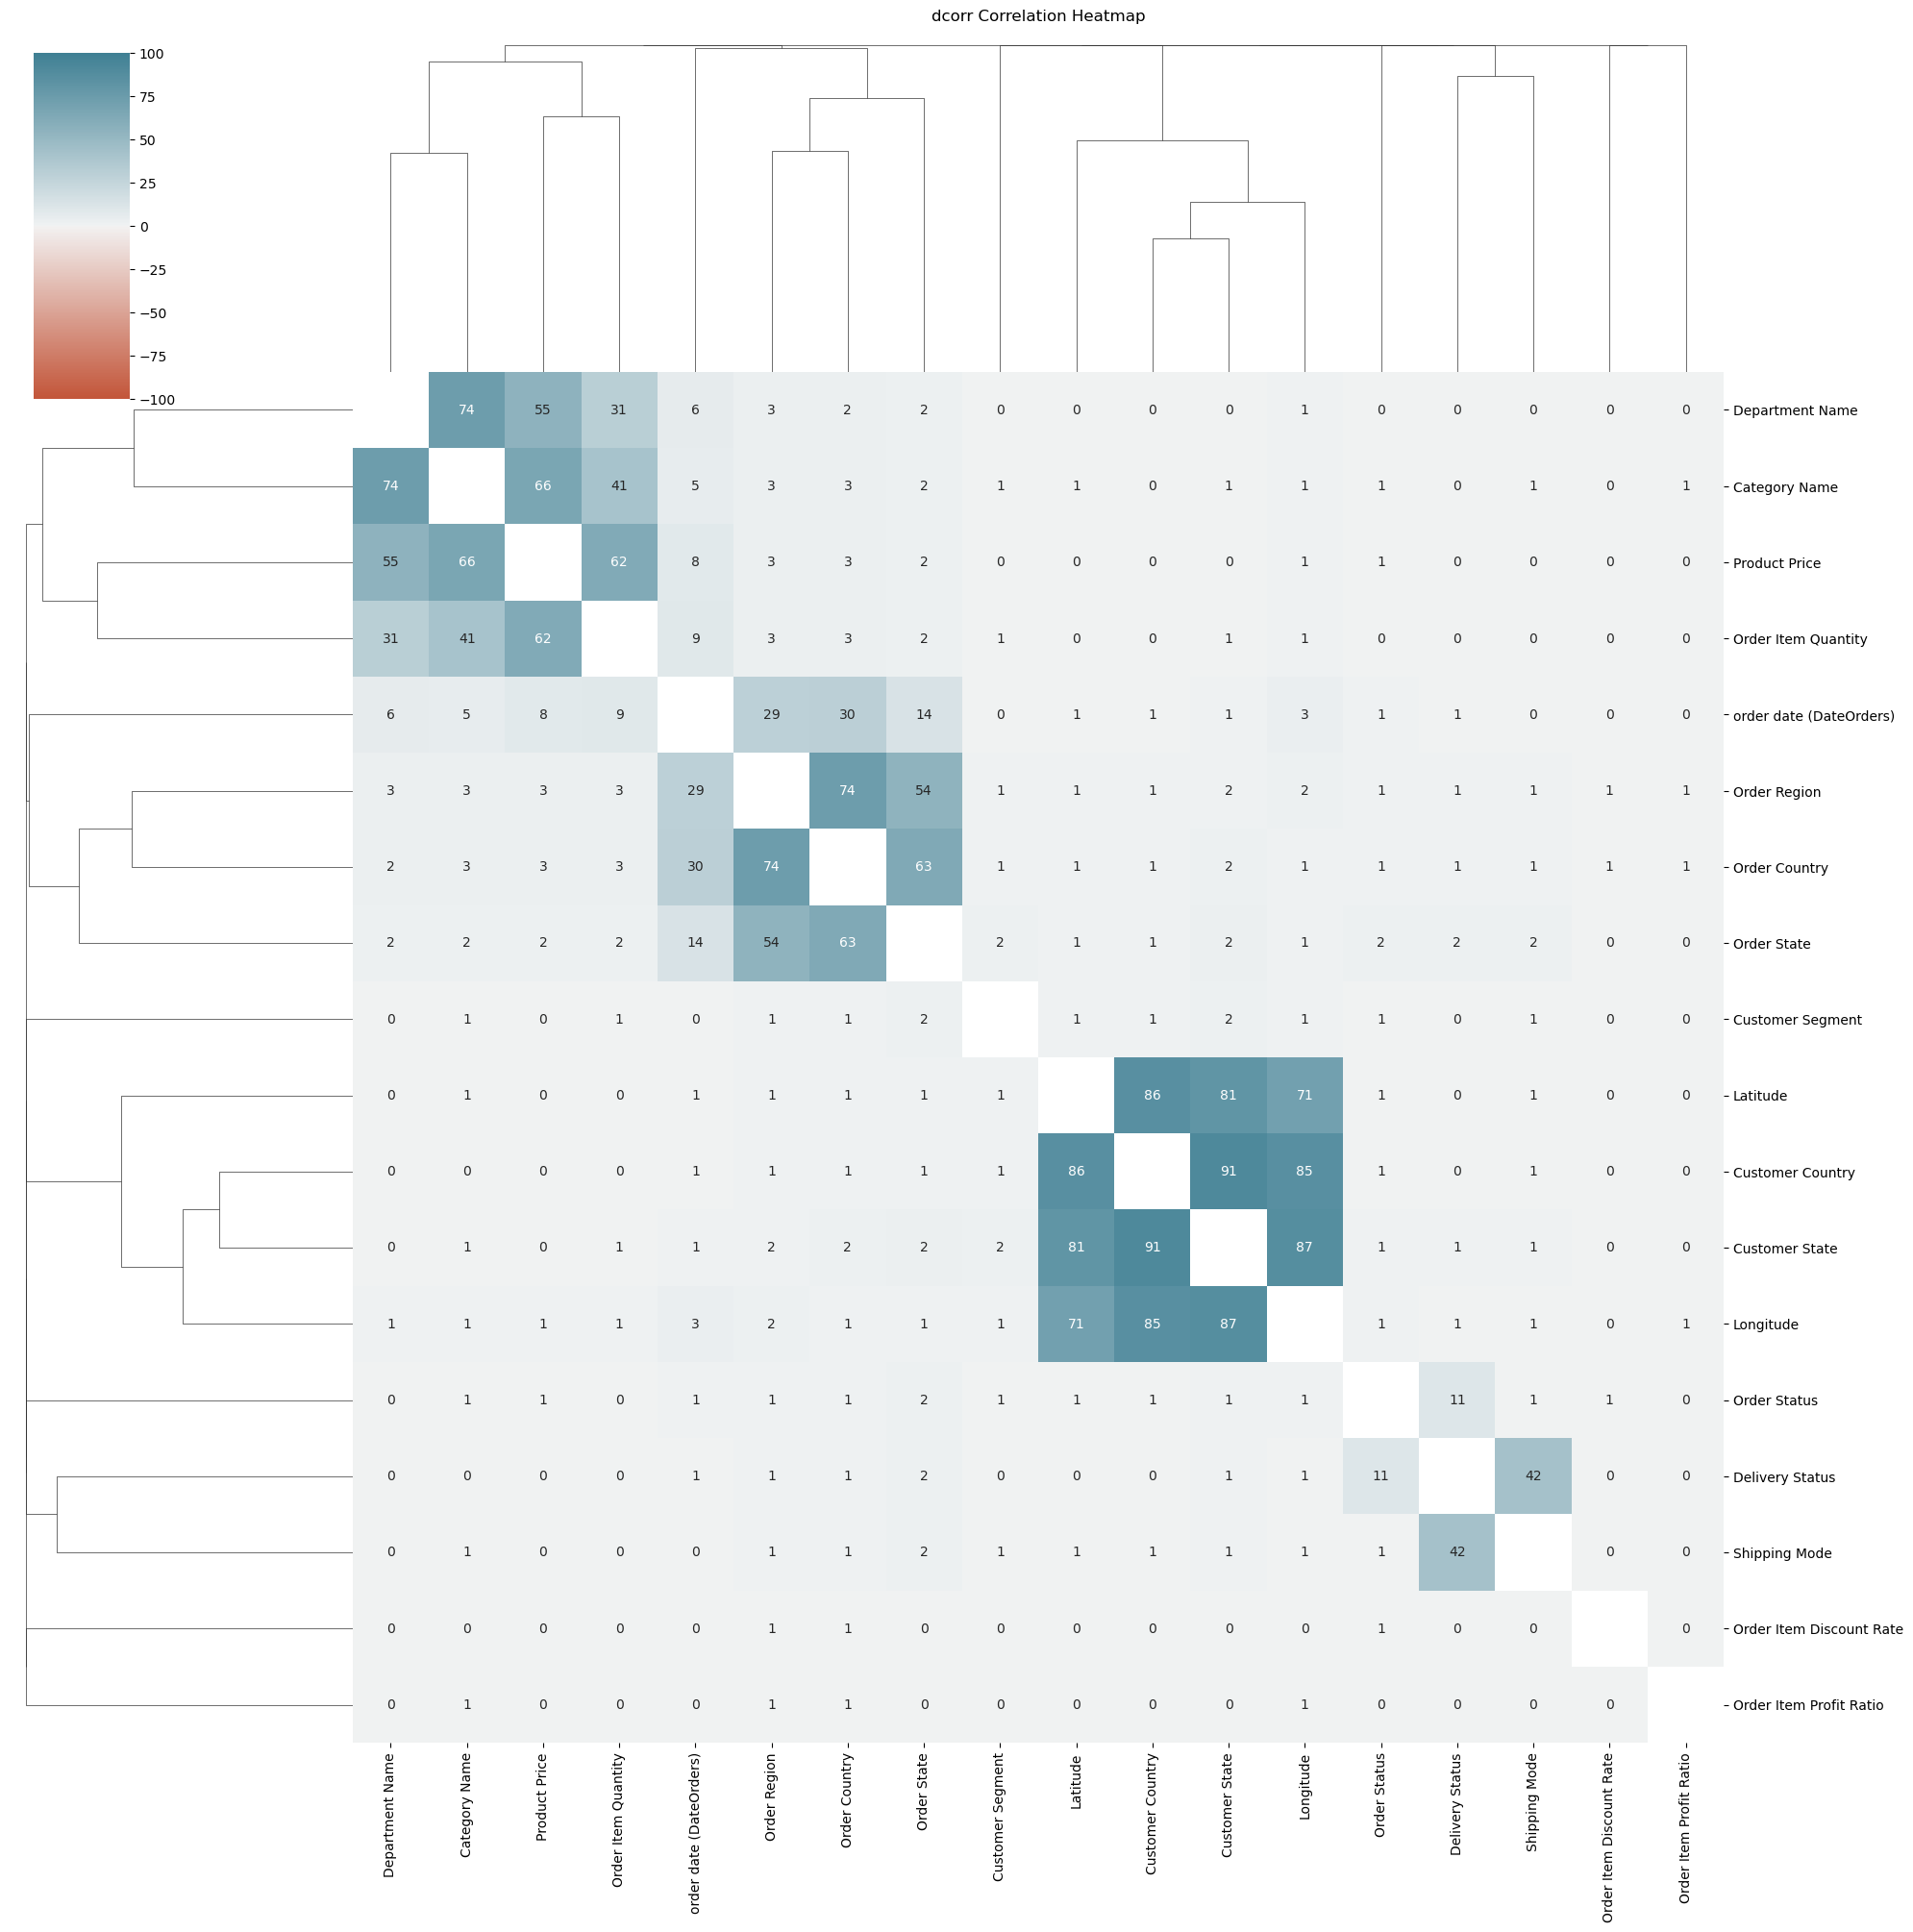

In [21]:
target = 'Delivery Status'
dta = pan.DataAnalyzer(df2, target=target, verbose=verbose,
                      cont_thres=cont_thres, random_state=random_state)

dta.corr_heatmap(corr_method='dcorr', figsize=(20, 20), cluster=True);

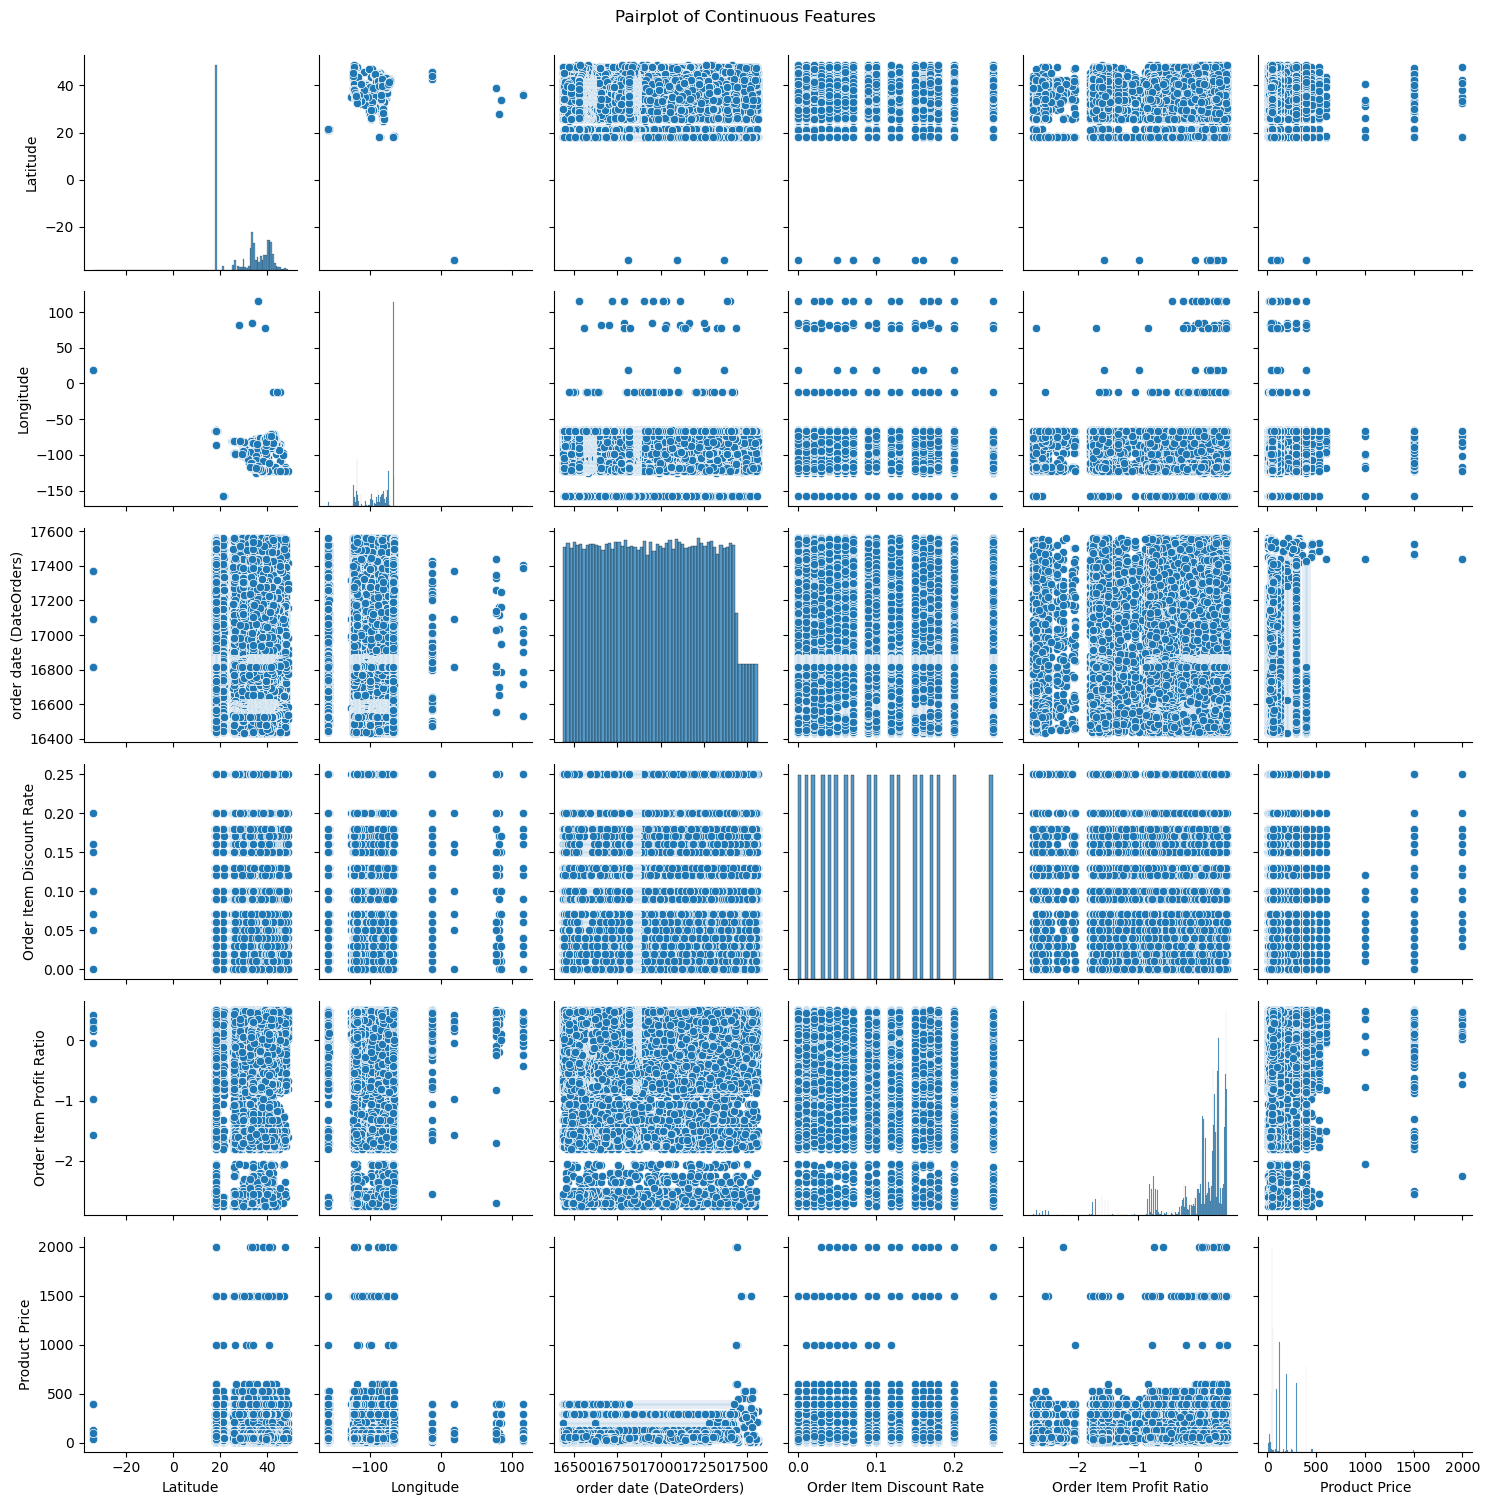

In [22]:
dta.pairplot();

In [ ]:
assert 0 == 1

In [ ]:
cont_cols = dta.cont_cols #[c for c in df.columns if (c not in [*dta.disc_cols, *dta.sparse_cols, 'IsDelay'])]

df_final = dta.df.copy()
df_final.to_csv('../Processed/DataCo.csv')
print(cont_cols)
df_final